# ML Challenge - [Fraud Detection in Electricity and Gas Comsumption](https://zindi.africa/competitions/fraud-detection-in-electricity-and-gas-consumption-challenge/data)



In [1]:
# Import libs
# utility libs
import os
import sys
from pathlib import Path
import pickle
from datetime import datetime
# DS and DV libs
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
# ML libs
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.linear_model import LogisticRegression, SGDClassifier
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.preprocessing import StandardScaler
# from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict
# from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, accuracy_score

## 1. Set up workdir

In [2]:
# set up work env
CURRENT_DIR = Path.cwd()
# please consider to change the value to find your root dir
ROOT_DIR = CURRENT_DIR.parents[0]
# data
DATA_DIR = os.path.join(ROOT_DIR, "data")
TRAIN_DIR = os.path.join(DATA_DIR, "train")
TEST_DIR = os.path.join(DATA_DIR, "test")
# models output dir
MODELS_DIR = os.path.join(ROOT_DIR, "models")
MODEL_FILE_NAME = "fraud_detection_elec_gaz.pkl"
MODEL_PATH = os.path.join(MODELS_DIR, MODEL_FILE_NAME)
# add root dir to sys path
sys.path.insert(0, str(ROOT_DIR))
# import custom palettes for data viz
import utils.dataviz_utils as custom_viz
# import help func for ML
import fraud_helper as fh
# from fraud_helper.ml_utils import *
# from fraud_helper.ml_config_utils import(
#     invoice_agg_dict, final_cols, missing_data_std_1, main_feature_cols,
#     features_sets, models
# )
# # prepare data for training
# MAX_ITER = 5000
# SEED = 42
# MODELS_NAME_NEEDING_SCALING = ["LogisticRegression", "SGDClassifier"]

[^v^] Seaborn configured with style: 'darkgrid', context: 'notebook'
[°-°] Matplotlib rcParams configured


In [3]:
# load files: invoice files are bigger, so we use the option low_memory to hide the pandas's warning
# train
client_train_df = pd.read_csv(os.path.join(TRAIN_DIR, "client_train.csv"))
invoice_train_df = pd.read_csv(os.path.join(TRAIN_DIR, "invoice_train.csv"), low_memory=False)
# test
client_test_df = pd.read_csv(os.path.join(TEST_DIR, "client_test.csv"))
invoice_test_df = pd.read_csv(os.path.join(TEST_DIR, "invoice_test.csv"), low_memory=False)

In [ ]:
# features configs
# maping_dict
# - client catg(3): [11, 12, 51], 
# - disrict(4): [60 69 62 63]
# take the agg content as a dict to automatate the process
# invoice_agg_dict = {
#     "consommation_level_1": ["count", "sum", "mean", "min", "max", "std"],
#     "consommation_level_2": ["count", "sum", "mean", "min", "max", "std"],
#     "consommation_level_3": ["count", "sum", "mean", "min", "max", "std"],
#     "consommation_level_4": ["count", "sum", "mean", "min", "max", "std"]
# }

# missing_data_std_1 = [
#         "consommation_level_1_count",
#         "consommation_level_1_mean",
#         "consommation_level_1_std"
# ]
# # close to the final df
# final_cols = [
#     "disrict", "client_catg", "region", "counter_type_nunique",
#     "consommation_level_1_min", "consommation_level_1_mean", "consommation_level_1_max", 
#     "consommation_level_2_min", "consommation_level_2_mean", "consommation_level_2_max", 
#     "consommation_level_3_min", "consommation_level_3_mean", "consommation_level_3_max", 
#     "consommation_level_4_min", "consommation_level_4_mean", "consommation_level_4_max", 
#     "target"
# ]
# # define main features
# main_feature_cols = [
#     "disrict", "client_catg", "region", "counter_type_nunique",
#     "consommation_level_1_mean", 
#     "consommation_level_2_mean",
#     "consommation_level_3_mean",
#     "consommation_level_4_mean"
# ]
# # all feats
# features_sets = {
#     "main_features": main_feature_cols,
#     "all_features": final_cols[: -1]
# }

# # model pipeline
# models = {
#     "RandomForestClassifier": {
#         "model": RandomForestClassifier(class_weight="balanced", random_state=SEED, n_jobs=-1),
#         "params": {
#             "criterion": ["gini", "entropy", "log_loss"],
#             "n_estimators": [50, 100, 200],
#             "max_depth": [None,  10]
#         }
#     },
#     "LogisticRegression": {
#         "model": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
#         "params": {
#             "solver": ["lbfgs", "liblinear", "saga"],
#             "C": [0.001, 0.01, 0.1, 1, 10]
#         }
#     },
#     "SGDClassifier":{
#         "model": SGDClassifier(max_iter=MAX_ITER, n_jobs=-1, random_state=SEED),
#         "params": {
#             "loss": ["log_loss"],
#             "penalty": ["l1", "l2"],
#             "alpha": [0.001, 0.01, 0.1],
#             "learning_rate": ["optimal"]
#         }
#     },
#     "DecisionTreeClassifier":{
#         "model": DecisionTreeClassifier(random_state=SEED),
#         "params": {
#             "criterion": ["gini", "entropy", "log_loss"],
#             "splitter": ["best", "random"],
#             "max_depth": [5, 10]
#         }
#     }
# }

In [ ]:
# setup help methods
# convert date to datetime
# def convert_to_pd_datetime(dfs:list[pd.DataFrame], col_name:str) -> None:
#     for df in dfs:
#         df[col_name] = pd.to_datetime(df[col_name], yearfirst=True)

# # define a function to agg invoice by client id
# def agg_invoice(invoice_df:pd.DataFrame, agg_feats: dict, agg_cond: str ="client_id"):
#     agg_df = invoice_df.groupby(agg_cond).agg(agg_feats)
#     # flatten the cols
#     agg_df.columns = ["_".join(col).strip() for col in agg_df.columns]
#     # reset the agg index
#     agg_df.reset_index(inplace=True)
#     return agg_df

# def agg_invoice_add_counter_type(invoice_df:pd.DataFrame, agg_df: pd.DataFrame, agg_cond: str ="client_id"):
#     tmp_invoice_copy_df = invoice_df.copy()
#     tmp_invoice_copy_df["has_elec"] = (tmp_invoice_copy_df["counter_type"] == "ELEC").astype(int)
#     tmp_invoice_copy_df["has_gaz"] = (tmp_invoice_copy_df["counter_type"] == "GAZ").astype(int)
#     # agg
#     agg_by_counter_type = tmp_invoice_copy_df.groupby(agg_cond).agg({
#         "has_elec": ["sum", "mean"],
#         "has_gaz": ["sum", "mean"],
#         "counter_type": ["nunique"] # how many different types the client has
#     })
#     # flatten the cols
#     agg_by_counter_type.columns = ["_".join(col).strip() for col in agg_by_counter_type.columns]
#     # reset the agg index
#     agg_by_counter_type.reset_index(inplace=True)
#     # merge with the existing agg df
#     agg_df = agg_df.merge(agg_by_counter_type, on=agg_cond, how="left")
#     return agg_df

# # create a copy of df
# def make_a_copy(df: pd.DataFrame):
#     return df.copy()

In [ ]:
# def plot_consumption_distribution(consumption_df, consumpt_cols, title):
    

#     fig, axes = plt.subplots(1, 3)
#     fig.suptitle(f"Consumption Level 1 ({title}): Missing vs Not Missing")

#     axes = axes.flatten()
#     for idx, col_name in enumerate(consumpt_cols):
#         sns.boxplot(
#         data=consumption_df,
#         x="missing_std_1",
#         y=col_name,
#         ax=axes[idx]
#         )

#     plt.title(f"{title} - Consumption Means\nMissing vs not Missing std")
#     plt.tight_layout()
#     plt.show()

# # scaling data (only if needed)
# def scale_features(X_train, X_test, apply_scaling=False):
#     """Apply scale on data only if requested"""
#     if not apply_scaling:
#         return X_train.values, X_test.values, None
#     scaler = StandardScaler()
#     X_train_scaled = scaler.fit_transform(X_train)
#     X_test_scaled = scaler.transform(X_test)

#     return X_train_scaled, X_test_scaled, scaler

# # train a single model
# def train_model(model_name, config, X_train, y_train, X_test, scoring="roc_auc", scale=False):
#     """Train a single model with or without scaling"""
#     print(f"\n{'':10} {model_name} (scaled: {scale})...")

#     X_tr, X_te, _ = scale_features(X_train, X_test, scale)
#     cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

#     grid_search = GridSearchCV(
#         config["model"],
#         config["params"],
#         cv=cv,
#         scoring=scoring,
#         n_jobs=-1,
#         verbose=2
#     )
#     grid_search.fit(X_tr, y_train)
    
#     return grid_search, X_tr, X_te

# # evaluate the model and store the summary
# def evaluate_and_store(grid_search, X_train, y_train, X_test, model_name, scale):
#     """predict and store metric prediction"""
#     # train
#     y_tr_pred = grid_search.predict(X_train)
#     train_acc = accuracy_score(y_train, y_tr_pred)
#     train_roc = None
#     if hasattr(grid_search.best_estimator_, "predict_proba"):
#         train_roc = roc_auc_score(y_train, grid_search.predict_proba(X_train)[:, 1])
#         # check overfitting gap
#         overfit_gap = train_roc - grid_search.best_score_
#         if overfit_gap > 0.1:
#             print(f"{'':15}Overfitting! Gap: {overfit_gap:.3f}")

#     # test
#     y_test_pred = grid_search.predict(X_test)
#     y_test_pred_proba = None
#     if hasattr(grid_search.best_estimator_, "predict_proba"):
#         y_test_pred_proba = grid_search.predict_proba(X_test)[:, 1]

#     # put evaluation summary in a dict
#     eval_summary = {
#         "model": model_name,
#         "scaled": scale,
#         "train_acc": train_acc,
#         "train_roc": train_roc,
#         "val_roc": grid_search.best_score_,
#         "y_pred": y_test_pred,
#         "y_pred_proba": y_test_pred_proba,
#         "best_model": grid_search.best_estimator_,
#         "best_params": grid_search.best_params_,
#         "overfitting_gap": overfit_gap
#     }
#     return eval_summary

In [ ]:
# run training
# def run_training(features_sets_dict, models_dict, X_train, y_train, X_test):
#     """Run training in all models with all thegiven sets and return a dataframe to analyse the results"""
#     results = []

#     for feature_name, features in features_sets_dict.items():
#         print(f"\n{'='*50}\nFEATURE SET: {feature_name}\n{'='*50}")

#         X_train_subset = X_train[features]
#         X_test_subset = X_test[features]

#         for model_name, config in models_dict.items():
#             # train without scaling
#             grid_search_not_scaled, X_train_not_scaled, X_test_not_scaled = train_model(
#                 model_name, config, X_train_subset, y_train,
#                 X_test_subset, scale=False
#             )
#             # add the result to the list
#             result = evaluate_and_store(
#                 grid_search_not_scaled, X_train_not_scaled, y_train,
#                 X_test_not_scaled, model_name, False
#             )
#             results.append(result)

#             # if scaling
#             if model_name in MODELS_NAME_NEEDING_SCALING:
#                 grid_search_scaled, X_train_scaled, X_test_scaled = train_model(
#                     model_name, config, X_train_subset, y_train,
#                     X_test_subset, scale=True
#                 )
#                 result = evaluate_and_store(
#                 grid_search_scaled, X_train_scaled, y_train,
#                 X_test_scaled, model_name, True
#             )
#     # convert the result to a dataframe
#     summary_df = pd.DataFrame(results)
#     return summary_df

In [ ]:
# get confusion matrix
# def plot_conf_mat_from_cv(model_name, config, X, y, scale=False):
#     X_scaled, _, _ = scale_features(X, X, scale)
#     # return prediction
#     y_cv_pred = cross_val_predict(config["model"], X_scaled, y, cv=3)
#     cm = confusion_matrix(y, y_cv_pred)

#     print(f"\n{'':25} Confusion Matrix (from cross val)")
#     print(f"\n{'':25} Model Name: {model_name})")
#     print(f"[[TN: {cm[0, 0]}, FP: {cm[0, 1]}]]")
#     print(f"[[FN: {cm[1, 0]}, TP: {cm[1, 1]}]]")

#     fig, ax = plt.subplots(figsize=(6, 4))
#     sns.heatmap(
#         data=cm, annot=True,
#         fmt="d", cmap=custom_viz.CMAP_PALETTE_02,
#         xticklabels=["No Fraud", "Fraud"],
#         yticklabels=["No Fraud", "Fraud"],
#         ax=ax
#     )
#     ax.set_title(f"{model_name} Confusion Matrix")
#     plt.show()

#     return cm

# # report
# def plot_classification_report_cv(model_name, config, X, y, scale=False):
#     "Plot classification report"
#     X_scaled, _, _ = scale_features(X, X, scale)
#     y_cv_pred = cross_val_predict(config["model"], X_scaled, y, cv=3)

#     report = classification_report(y, y_cv_pred, output_dict=True)
#     report_df = pd.DataFrame(report)
#     print(f"\nReport (before transpose):\n{report_df}")
#     report_df = report_df.transpose()
#     print(f"\nReport (after transpose):\n{report_df}")
#     # plot
#     fig, ax = plt.subplots(figsize=(8, 3))
#     sns.heatmap(
#         report_df[["precision", "recall", "f1-score"]],
#         annot=True, fmt=".3f", cmap="RdYlGn", ax=ax
#     )
#     ax.set_title(f"Classification Report: {model_name}")
#     plt.show()

#     return report_df

# # plot summary
# def plot_models_summary(summary_df):
#     # display best model
#     best_model = summary_df.loc[summary_df["val_roc"].idxmax()]

#     print(f"\n    BEST MODEL: {best_model['model']} (scaled: {best_model['scaled']})")
#     print(f"{'':10}Val ROC-AUC: {best_model['val_roc']:.3f}")
#     print(f"{'':10}Train ROC-AUC: {best_model['train_roc']:.3f}")
#     x = np.arange(len(summary_df))
#     plt.bar(x, summary_df["val_roc"], color=custom_viz.PALETTE_BLUE[3])
#     plt.xticks(
#         x, 
#         [f"{m}\n({'Scaled' if s else 'Not Scaled'})" for m, s in zip(summary_df["model"], summary_df["scaled"])],
#         rotation=45, ha="right"
#     )
#     plt.title("Cross Val score ROC")
#     plt.tight_layout()
#     plt.show()

# # plot overfitting gap
# def plot_overfitting_detection(summary_df):
#     sns.barplot(
#         data=summary_df,
#         x="val_roc",
#         y="model",
#         hue="scaled",
#         palette=custom_viz.MIXED_PALETTE[:2]
#     )
#     plt.title("Validation ROC AUC")
#     plt.xlabel("ROC-AUC")
#     plt.tight_layout()
#     plt.show()

#     # overfitting heatmap
#     pivot_df = summary_df.pivot_table(
#         values="overfitting_gap",
#         index="model", columns="scaled"
#     )
#     sns.heatmap(
#         data=pivot_df, annot=True, cmap="RdYlGn_r",
#         center=0.05
#     )
#     plt.title("Overfitting gap (Train - Val)")
#     # plt.tight_layout()
#     plt.show()

In [ ]:
# # Real vs predicted fraud distribution
# def plot_fraud_distribution(X_train, y_train, training_summary, main_feature_cols, final_cols):
#     best_row = training_summary.loc[training_summary["val_roc"].idxmax()]
#     best_model = best_row["best_model"]
    
#     features_set_used = best_row.get("features_set", "all_features")
#     if features_set_used == "main_features":
#         features_used = main_feature_cols
#     else:
#         features_used = final_cols[: -1]
#     # Predict on train data
#     X_features = X_train[features_used]
#     y_pred_train = best_model.predict(X_features.values)
    
#     # Plot
#     plt.figure(figsize=(8, 5))
#     plt.bar(
#         ["Real No Fraud", "Real Fraud", "Pred No Fraud", "Pred Fraud"],
#         [
#             (y_train == 0).sum(), (y_train == 1).sum(),
#             (y_pred_train == 0).sum(), (y_pred_train == 1).sum()
#         ],
#         color=['#4CAF50', '#F44336', '#4CAF50', '#F44336'],
#         alpha=0.7
#     )
#     plt.title(f'Fraud Distribution: Real vs Predicted ({features_set_used})', fontweight='bold')
#     plt.ylabel('Client Count')
#     plt.xlabel('')
#     plt.legend(title='Fraud')
#     plt.tight_layout()
#     plt.legend()
#     plt.show()
#     # Print stats
#     print(f"Model: {best_row['model']}")
#     print(f"Feature set: {features_set_used} ({len(features_used)} features)")
#     print(f"Real fraud: {(y_train == 1).sum()} ({(y_train == 1).mean():.1%})")
#     print(f"Pred fraud: {(y_pred_train == 1).sum()} ({(y_pred_train == 1).mean():.1%})")

In [ ]:
# def analyze_counter_type_fraud(train_data_df):
#     """Analyze fraud by number of counter types"""
#     # Fraud rate by number of counter types
#     rate_by_type = train_data_df.groupby('counter_type_nunique')['target'].agg(['count', 'mean']).round(3)
#     rate_by_type.columns = ['Client_Count', 'Fraud_Rate']
    
#     print("\nFRAUD RATE BY COUNTER TYPE COUNT:")
#     print(rate_by_type)
    
#     # Plot
#     plt.figure(figsize=(8, 4))
#     sns.barplot(data=rate_by_type.reset_index(), x='counter_type_nunique', y='Fraud_Rate', palette=custom_viz.MIXED_PALETTE[:2])
#     plt.title('Fraud Rate by Number of Counter Types')
#     plt.xlabel('Number of Counter Types')
#     plt.ylabel('Fraud Rate')
#     plt.ylim(0, rate_by_type['Fraud_Rate'].max() * 1.2)
#     plt.show()
    
#     return rate_by_type

In [ ]:
# def analyze_energy_type_fraud(original_train_df):
#     """Analyze fraud by energy type (ELEC vs GAZ) - needs original dataframe"""
#     # Check if columns exist
#     if 'has_elec_sum' not in original_train_df.columns:
#         print("ERROR: Need original train_data_df with has_elec_sum column!")
#         print(f"Available columns: {original_train_df.columns.tolist()}")
#         return None
    
#     # Clients with single counter type only
#     single_type = original_train_df[original_train_df['counter_type_nunique'] == 1].copy()
    
#     # Determine energy type
#     single_type['energy_type'] = np.where(single_type['has_elec_sum'] > 0, 'ELEC', 'GAZ')
    
#     # Calculate fraud rates
#     energy_rate = single_type.groupby('energy_type')['target'].agg(['count', 'mean']).round(3)
#     energy_rate.columns = ['Client_Count', 'Fraud_Rate']
    
#     print("\nFRAUD RATE BY ENERGY TYPE (Single Counter):")
#     print(energy_rate)
    
#     # Plot
#     plt.figure(figsize=(6, 4))
#     sns.barplot(data=energy_rate.reset_index(), x='energy_type', y='Fraud_Rate', 
#                 palette={'ELEC': custom_viz.MIXED_PALETTE[1], 'GAZ': custom_viz.MIXED_PALETTE[0]})
#     plt.title('Fraud Rate by Energy Type (Single Counter)')
#     plt.ylabel('Fraud Rate')
#     plt.show()
    
#     return energy_rate

In [ ]:
# def fraud_rate_catg_features(train_df, features=["client_catg", "region", "disrict"]):
#     for feature in features:
#         print(f"\n{'='*50}")
#         print(f"FRAUD BY RATE - {feature.upper()}")
#         print(f"{'='*50}")

#         rate = train_df.groupby(feature)["target"].agg(["count", "mean"]).round(3)
#         rate.columns = ["Count", "Fraud_Rate"]
#         rate = rate.sort_values("Fraud_Rate", ascending=False)
#         print(rate.head(5))
#         # plot
#         sns.barplot(
#             data=rate.head(5).reset_index(),
#             x="Fraud_Rate", y=feature
#         )
#         plt.title(f"Top 5 {feature} by Fraud Rate")
#         plt.xlabel("Fraud Rate")
#         plt.show()

#         # show highest
#         print(f"\nHighest fraud rate: {rate.iloc[0]['Fraud_Rate']:.1%} (Category: {rate.index[0]})")

In [ ]:
# def interpret_model_summary(training_summary, df):
#     best = training_summary.loc[training_summary["val_roc"].idxmax()]
#     print(f"\nBEST: {best['model']} | ROC-AUC: {best['val_roc']:.3f}")
    
#     # Check if multi-counter = more fraud
#     if 'counter_type_nunique' in df.columns:
#         multi = df[df['counter_type_nunique'] > 1]['target'].mean()
#         single = df[df['counter_type_nunique'] == 1]['target'].mean()
#         print(f"Multi-counter fraud: {multi:.1%} | Single: {single:.1%}")
#         print(f"Ratio: {multi/single:.1f}x more fraud" if single > 0 else "N/A")
    
#     # Performance interpretation
#     if best['val_roc'] > 0.75:
#         print("  EXCELLENT fraud detection")
#     elif best['val_roc'] > 0.65:
#         print("  GOOD performance")
#     else:
#         print("  NEEDS IMPROVEMENT")

# def save_best_model(training_summary, train_samples, features_sets, output_path, author_name="Rackkoun"):
#     best_row = training_summary.iloc[training_summary["val_roc"].idxmax()]

#     # get actual features
#     if "features_set" in best_row:
#         features_set_name = best_row["features_set"]
#         features_set_used = features_sets[features_set_name]
#     else:
#         # figure out from model
#         model = best_row["best_model"]
#         if model.n_features_in_ == len(features_sets["main_features"]):
#             features_set_used = features_sets["main_features"]
#             features_set_name = "main_features"
#         else:
#             features_set_used = features_sets["all_features"]
#             features_set_name = "all_features"
#     print(f"Saving model trained with: {features_set_name} ({len(features_set_used)})")
#     model_package = {
#         "model": best_row["best_model"],
#         "metadata": {
#             "author": author_name,
#             "model_name": best_row["model"],
#             "val_roc_auc": best_row["val_roc"],
#             "overfitting_gap": best_row["overfitting_gap"],
#             "best_params": best_row.get("best_params", {}),
#             "saved_date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
#             "features_set": features_set_name,
#             "features_used": features_set_used,#main_feature_cols,
#             "n_features": len(features_set_used),
#             "n_samples": len(train_samples)#len(X_train)
#         }
#     }
#     # create models dir if not exist
#     # MODEL_PATH = os.path.join(MODELS_DIR, MODEL_FILE_NAME)
#     os.makedirs(os.path.dirname(output_path), exist_ok=True)

#     # save to file
#     with open(output_path, "wb") as model_file:
#         pickle.dump(model_package, model_file)
#     print(f"Model saved to: {output_path}")
#     print(f"Author: {author_name}")
#     print(f"ROC-AUC: {best_row['val_roc']:.3f}")
#     return model_package

In [ ]:
# def load_model(model_path):
#     """Load model package from disk"""
#     with open(model_path, "rb") as model_file:
#         model_pkg = pickle.load(model_file)
    
#     model = model_pkg["model"]
#     metadata = model_pkg["metadata"]

#     print(f"Model loaded from: {model_path}")
#     print(f"{''*10}Author: {metadata['author']}")
#     print(f"{''*10}ROC-AUC: {metadata['val_roc_auc']}")
#     print(f"{''*10}Features: {metadata['features_used']}")

#     return model, metadata

## 2. EDA

__2.1. Explore the data__

In [16]:
# train data
print("="*100)
print(f"\n{'='*10} Client(Train) {client_train_df.shape} {'='*20}") # shape: (135493, 6)
print(client_train_df.head(3))

print(f"\n{'='*10} Invoice(Train) {invoice_train_df.shape} {'='*20}") # shape: (4476749, 16)
print(invoice_train_df.head(3))

print(f"\n{'='*10} Client(Test) {client_test_df.shape} {'='*20}") # shape: (58069, 5)
print(client_test_df.head(3))

print(f"\n{'='*10} Invoice(Test) {invoice_test_df.shape} {'='*20}") # shape: (1939730, 16)
print(invoice_test_df.head(3))


========== Client(Train) (135493, 6) ====================
   disrict        client_id  client_catg  region creation_date  target
0       60   train_Client_0           11     101    31/12/1994     0.0
1       69   train_Client_1           11     107    29/05/2002     0.0
2       62  train_Client_10           11     301    13/03/1986     0.0

========== Invoice(Train) (4476749, 16) ====================
        client_id invoice_date  tarif_type  counter_number counter_statue   
0  train_Client_0   2014-03-24          11         1335667              0  \
1  train_Client_0   2013-03-29          11         1335667              0   
2  train_Client_0   2015-03-23          11         1335667              0   

   counter_code  reading_remarque  counter_coefficient  consommation_level_1   
0           203                 8                    1                    82  \
1           203                 6                    1                  1200   
2           203                 8             

In [17]:
# info
# date format should be converted
client_train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135493 entries, 0 to 135492
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   disrict        135493 non-null  int64  
 1   client_id      135493 non-null  object 
 2   client_catg    135493 non-null  int64  
 3   region         135493 non-null  int64  
 4   creation_date  135493 non-null  object 
 5   target         135493 non-null  float64
dtypes: float64(1), int64(3), object(2)
memory usage: 6.2+ MB


In [18]:
# date format should be converted to pd datetime
invoice_train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4476749 entries, 0 to 4476748
Data columns (total 16 columns):
 #   Column                Dtype 
---  ------                ----- 
 0   client_id             object
 1   invoice_date          object
 2   tarif_type            int64 
 3   counter_number        int64 
 4   counter_statue        object
 5   counter_code          int64 
 6   reading_remarque      int64 
 7   counter_coefficient   int64 
 8   consommation_level_1  int64 
 9   consommation_level_2  int64 
 10  consommation_level_3  int64 
 11  consommation_level_4  int64 
 12  old_index             int64 
 13  new_index             int64 
 14  months_number         int64 
 15  counter_type          object
dtypes: int64(12), object(4)
memory usage: 546.5+ MB


In [19]:
# client_id has a col with the same name in invoice; can be used to merge both
print(f"Client unique: {client_train_df.client_id.nunique()}\nValues: {client_train_df.client_id.unique()}")

Client unique: 135493
Values: ['train_Client_0' 'train_Client_1' 'train_Client_10' ...
 'train_Client_99997' 'train_Client_99998' 'train_Client_99999']


In [20]:
# display uniqu values in any cols
# - client catg(3): [11, 12, 51], 
# - disrict(4): [60 69 62 63]
# - target(2): [0.0, 1.0] can be changed as categ var
print(f"{'='*10} Client Train {'='*20}")
for col in client_train_df:
    print(f"{'='*5}\n{col}: N ({client_train_df[col].nunique()}) {'='*10}\n{client_train_df[col].unique()}\n")

========== Client Train ====================
=====
disrict: N (4) ==========
[60 69 62 63]

=====
client_id: N (135493) ==========
['train_Client_0' 'train_Client_1' 'train_Client_10' ...
 'train_Client_99997' 'train_Client_99998' 'train_Client_99999']

=====
client_catg: N (3) ==========
[11 12 51]

=====
region: N (25) ==========
[101 107 301 105 303 103 309 311 304 104 312 305 306 308 372 307 313 310
 371 302 106 379 399 206 199]

=====
creation_date: N (8088) ==========
['31/12/1994' '29/05/2002' '13/03/1986' ... '16/08/2004' '30/08/1978'
 '25/05/1978']

=====
target: N (2) ==========
[0. 1.]



In [21]:
# counter status has mixed dtypes values: e.g. A, 0 etc.
# is reading_remarque relevant for the fraud detection?
# counter type(2): ["ELEC", "GAZ"] -> catg
print(f"{'='*10} Invoice Train {'='*20}")
for col in invoice_train_df:
    print(f"{'='*5}\n{col}: N ({invoice_train_df[col].nunique()}) {'='*10}\n{invoice_train_df[col].unique()}\n")

========== Invoice Train ====================
=====
client_id: N (135493) ==========
['train_Client_0' 'train_Client_1' 'train_Client_10' ...
 'train_Client_99997' 'train_Client_99998' 'train_Client_99999']

=====
invoice_date: N (8275) ==========
['2014-03-24' '2013-03-29' '2015-03-23' ... '1995-11-28' '1982-07-04'
 '1996-09-02']

=====
tarif_type: N (17) ==========
[11 40 15 10 12 14 13 45 29  9 30  8 21 42 27 18 24]

=====
counter_number: N (201893) ==========
[1335667  678902  572765 ... 4811719  262195  560948]

=====
counter_statue: N (12) ==========
['0' '1' '5' '4' '3' '2' '769' 'A' '618' '269375' '46' '420']

=====
counter_code: N (42) ==========
[203 207 413   5 467 202 420 410  10 483  25 433 407 204 214 442 453 506
 450 403 333 201 102 305 210 101 532  40 310 565 600 307 303 222  65   0
 227 325  16 317 367   1]

=====
reading_remarque: N (8) ==========
[  8   6   9   7 207 413 203   5]

=====
counter_coefficient: N (16) ==========
[ 1  3  0 10  4 33 50 20  2  6 40  9 30  5

In [22]:
# the data set seems to do not have any missing values
client_train_df.isna().sum()

disrict          0
client_id        0
client_catg      0
region           0
creation_date    0
target           0
dtype: int64

In [23]:
invoice_train_df.isna().sum()

client_id               0
invoice_date            0
tarif_type              0
counter_number          0
counter_statue          0
counter_code            0
reading_remarque        0
counter_coefficient     0
consommation_level_1    0
consommation_level_2    0
consommation_level_3    0
consommation_level_4    0
old_index               0
new_index               0
months_number           0
counter_type            0
dtype: int64

In [24]:
# duplicated?
invoice_train_df[invoice_train_df.duplicated()]

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,counter_type
951893,train_Client_125864,2011-12-12,11,101545,5,413,6,1,0,0,0,0,13680,13680,2,ELEC
1755798,train_Client_25894,2010-07-13,40,6986740,5,5,6,1,0,0,0,0,0,0,2,GAZ
2137999,train_Client_3636,2012-01-18,40,312650,5,5,6,1,0,0,0,0,623,623,2,GAZ
2163374,train_Client_37069,2010-10-11,11,5284,5,413,6,1,0,0,0,0,99429,99429,2,ELEC
2433919,train_Client_44407,2008-02-28,11,66921,5,203,6,1,0,0,0,0,0,0,2,ELEC
2805729,train_Client_54609,2010-04-06,11,200912,5,207,6,1,0,0,0,0,0,0,2,ELEC
3260191,train_Client_66981,2006-07-17,11,132701,5,420,6,1,0,0,0,0,5946,5946,2,ELEC
3260198,train_Client_66981,2006-07-17,11,132701,5,420,6,1,0,0,0,0,5946,5946,2,ELEC
3394719,train_Client_7066,2014-10-28,40,4463323,5,5,6,1,0,0,0,0,80,80,2,GAZ
3462929,train_Client_72519,2013-01-21,11,246464,5,203,6,1,0,0,0,0,2954,2954,2,ELEC


In [25]:
# no clear duplicated entries?!!!
invoice_train_df[invoice_train_df["client_id"] == "train_Client_125864"]

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,counter_type
951847,train_Client_125864,2017-05-26,40,15139,0,5,9,1,788,0,0,0,6839,7627,4,GAZ
951848,train_Client_125864,2019-04-02,40,15139,0,5,8,1,931,0,0,0,7627,8558,20,GAZ
951849,train_Client_125864,2011-11-10,40,15139,0,5,6,1,311,0,0,0,570,881,8,GAZ
951850,train_Client_125864,2014-05-02,11,571507,0,413,8,1,400,120,0,0,16384,16904,2,ELEC
951851,train_Client_125864,2015-05-02,40,15139,0,5,9,1,599,0,0,0,3702,4301,4,GAZ
951852,train_Client_125864,2015-05-02,11,571507,0,413,8,1,800,400,579,0,22223,24002,4,ELEC
951853,train_Client_125864,2014-02-10,40,15139,0,5,6,1,220,0,0,0,3482,3702,4,GAZ
951854,train_Client_125864,2014-02-10,11,571507,0,413,9,1,800,400,800,2113,18110,22223,4,ELEC
951855,train_Client_125864,2008-06-10,40,15139,0,5,6,1,0,0,0,0,310,310,4,GAZ
951856,train_Client_125864,2006-09-19,40,15139,0,5,6,1,0,0,0,0,267,267,4,GAZ


In [26]:
# numerical cols in client df
client_test_df.describe()

,disrict,client_catg,region
count,58069.000000,58069.000000,58069.000000
mean,63.510617,11.507224,206.018461
std,3.356708,4.395923,104.144028
min,60.000000,11.000000,101.000000
25%,62.000000,11.000000,103.000000
50%,62.000000,11.000000,107.000000
75%,69.000000,11.000000,307.000000
max,69.000000,51.000000,399.000000


In [27]:
# nums cols for invoce
invoice_train_df.describe()

,tarif_type,counter_number,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number
count,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06
mean,2.012804e+01,1.230587e+11,1.724884e+02,7.321702e+00,1.003040e+00,4.109795e+02,1.093225e+02,2.030620e+01,5.292588e+01,1.776700e+04,1.834970e+04,4.483095e+01
std,1.347256e+01,1.657267e+12,1.338871e+02,1.571654e+00,3.083466e-01,7.573080e+02,1.220123e+03,1.574239e+02,8.754725e+02,4.036693e+04,4.095321e+04,3.128335e+03
min,8.000000e+00,0.000000e+00,0.000000e+00,5.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.100000e+01,1.211080e+05,5.000000e+00,6.000000e+00,1.000000e+00,7.900000e+01,0.000000e+00,0.000000e+00,0.000000e+00,1.791000e+03,2.056000e+03,4.000000e+00
50%,1.100000e+01,4.945610e+05,2.030000e+02,8.000000e+00,1.000000e+00,2.740000e+02,0.000000e+00,0.000000e+00,0.000000e+00,7.690000e+03,8.192000e+03,4.000000e+00
75%,4.000000e+01,1.115161e+06,2.070000e+02,9.000000e+00,1.000000e+00,6.000000e+02,0.000000e+00,0.000000e+00,0.000000e+00,2.166000e+04,2.234300e+04,4.000000e+00
max,4.500000e+01,2.798115e+13,6.000000e+02,4.130000e+02,5.000000e+01,9.999100e+05,9.990730e+05,6.449200e+04,5.479460e+05,2.800280e+06,2.870972e+06,6.366240e+05


In [28]:
# number of not fraud : 127927
client_train_df[client_train_df["target"] == 0].count()

disrict          127927
client_id        127927
client_catg      127927
region           127927
creation_date    127927
target           127927
dtype: int64

In [107]:
# make sense to have less fraudulent client
# 94,42% not fraud
# 5,58% fraud
client_fraud_distribution = client_train_df.groupby("target", as_index=False)["client_id"].agg({
    "fraudulent_client": ["count"]
})
client_fraud_distribution.columns = ["_".join(col).strip() for col in client_fraud_distribution.columns]
client_fraud_distribution

,target_,fraudulent_client_count
0,0.0,127927
1,1.0,7566


In [30]:
client_fraud_distribution.columns

Index(['target_', 'fraudulent_client_count'], dtype='object')

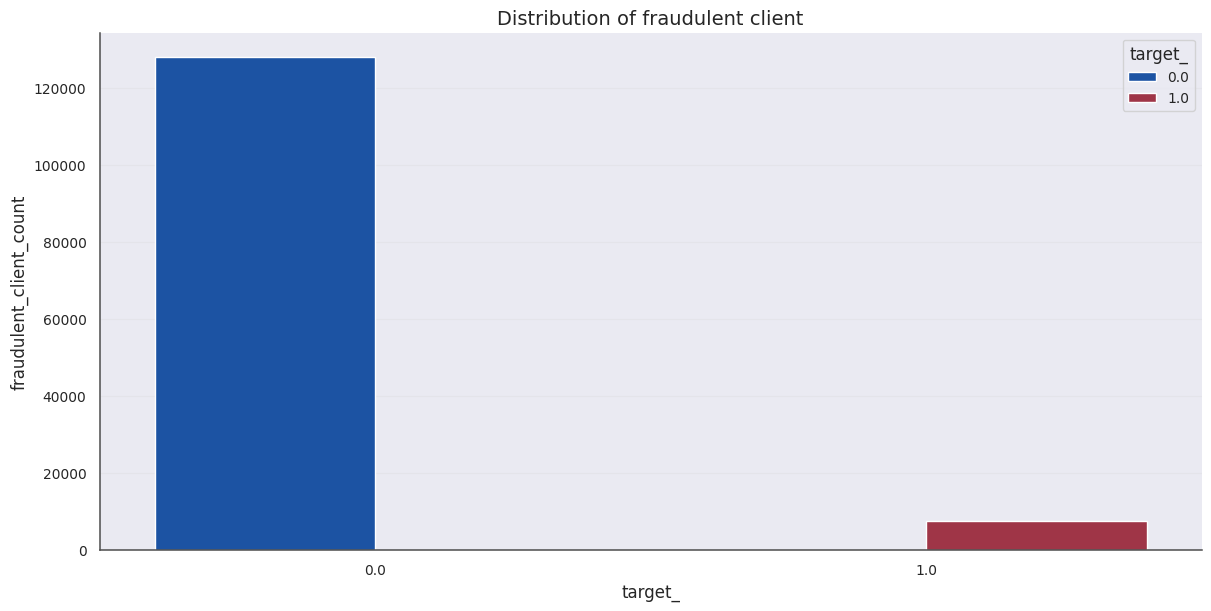

In [108]:
bar_ax = sns.barplot(
    data=client_fraud_distribution,
    x="target_",
    y="fraudulent_client_count",
    hue="target_",
    palette={
        0.0: custom_viz.PALETTE_BLUE[3],
        1.0: custom_viz.PALETTE_RED[3]
    }
)
plt.title("Distribution of fraudulent client")
plt.show()

__2.2 Preproprocess the data__

In [32]:
# help meths


In [4]:
# create a copy of all df
# train
client_train_df_00 = fh.make_a_copy(client_train_df)
invoice_train_df_00 = fh.make_a_copy(invoice_train_df)
# test
client_test_df_00 = fh.make_a_copy(client_test_df)
invoice_test_df_00 = fh.make_a_copy(invoice_test_df)


In [34]:
invoice_train_df_00.groupby("client_id").agg({
    "counter_type": ["first", "last"],
    "tarif_type": ["first", "last"],
    "counter_statue": ["first", "last"],
    "counter_code": ["first", "last"],
    "reading_remarque": ["first", "last"],
    "counter_coefficient": ["first", "last"],
}).head(10)

counter_type       tarif_type      counter_statue        
                           first  last      first last          first last   
client_id                                                                    
train_Client_0              ELEC  ELEC         11   11              0    0  \
train_Client_1              ELEC  ELEC         11   11              0    0   
train_Client_10             ELEC  ELEC         11   11              0    0   
train_Client_100            ELEC  ELEC         11   11              0    0   
train_Client_1000           ELEC  ELEC         11   11              0    0   
train_Client_10000           GAZ   GAZ         40   40              0    0   
train_Client_100000         ELEC  ELEC         11   11              1    0   
train_Client_100001          GAZ   GAZ         40   40              0    0   
train_Client_100002         ELEC  ELEC         11   11              0    0   
train_Client_100003         ELEC  ELEC         11   11              0    0   

                    counter_code      reading_remarque        
                           first last            first last   
client_id                                                     
train_Client_0               203  203                8    6  \
train_Client_1               203  203                8    8   
train_Client_10              203  203                8    6   
train_Client_100             413  413                6    6   
train_Client_1000            207  207                9    9   
train_Client_10000             5    5                9    6   
train_Client_100000          413  413                6    6   
train_Client_100001            5    5                8    6   
train_Client_100002          413  413                9    6   
train_Client_100003          467  467                9    9   

                    counter_coefficient       
                                  first last  
client_id                                     
train_Client_0                        1    1  
train_Client_1                        1    1  
train_Client_10                       1    1  
train_Client_100                      1    1  
train_Client_1000                     1    1  
train_Client_10000                    1    1  
train_Client_100000                   1    1  
train_Client_100001                   1    1  
train_Client_100002                   1    1  
train_Client_100003                   1    1

In [35]:
invoice_train_df_00.head(10)

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,counter_type
0,train_Client_0,2014-03-24,11,1335667,0,203,8,1,82,0,0,0,14302,14384,4,ELEC
1,train_Client_0,2013-03-29,11,1335667,0,203,6,1,1200,184,0,0,12294,13678,4,ELEC
2,train_Client_0,2015-03-23,11,1335667,0,203,8,1,123,0,0,0,14624,14747,4,ELEC
3,train_Client_0,2015-07-13,11,1335667,0,207,8,1,102,0,0,0,14747,14849,4,ELEC
4,train_Client_0,2016-11-17,11,1335667,0,207,9,1,572,0,0,0,15066,15638,12,ELEC
5,train_Client_0,2017-07-17,11,1335667,0,207,9,1,314,0,0,0,15638,15952,8,ELEC
6,train_Client_0,2018-12-07,11,1335667,0,207,9,1,541,0,0,0,15952,16493,12,ELEC
7,train_Client_0,2019-03-19,11,1335667,0,207,9,1,585,0,0,0,16493,17078,8,ELEC
8,train_Client_0,2011-07-22,11,1335667,0,203,9,1,1200,186,0,0,7770,9156,4,ELEC
9,train_Client_0,2011-11-22,11,1335667,0,203,6,1,1082,0,0,0,9156,10238,4,ELEC


In [5]:
# convert date for all data
fh.convert_to_pd_datetime([client_train_df_00, client_test_df_00], "creation_date")
fh.convert_to_pd_datetime([invoice_train_df_00, invoice_test_df_00], "invoice_date")

/home/rackkoun/Documents/Workspaces/neuefishe/projects/week-07/ds-ml-project/fraud_helper/data_utils.py:10: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[col_name] = pd.to_datetime(df[col_name], yearfirst=True)
/home/rackkoun/Documents/Workspaces/neuefishe/projects/week-07/ds-ml-project/fraud_helper/data_utils.py:10: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[col_name] = pd.to_datetime(df[col_name], yearfirst=True)


In [37]:
client_train_df_00.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135493 entries, 0 to 135492
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   disrict        135493 non-null  int64         
 1   client_id      135493 non-null  object        
 2   client_catg    135493 non-null  int64         
 3   region         135493 non-null  int64         
 4   creation_date  135493 non-null  datetime64[ns]
 5   target         135493 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 6.2+ MB


In [6]:
# agg invoice (do the same for test set)
invoice_train_df_agg = fh.agg_invoice(invoice_train_df_00, fh.invoice_agg_dict)
invoice_train_df_agg = fh.agg_invoice_add_counter_type(invoice_train_df_00, invoice_train_df_agg)

In [112]:
invoice_train_df_agg.head()

,client_id,consommation_level_1_count,consommation_level_1_sum,consommation_level_1_mean,consommation_level_1_min,consommation_level_1_max,consommation_level_1_std,consommation_level_2_count,consommation_level_2_sum,consommation_level_2_mean,consommation_level_2_min,consommation_level_2_max,consommation_level_2_std,consommation_level_3_count,consommation_level_3_sum,consommation_level_3_mean,consommation_level_3_min,consommation_level_3_max,consommation_level_3_std,consommation_level_4_count,consommation_level_4_sum,consommation_level_4_mean,consommation_level_4_min,consommation_level_4_max,consommation_level_4_std,has_elec_sum,has_elec_mean,has_gaz_sum,has_gaz_mean,counter_type_nunique
0,train_Client_0,35,12334,352.400000,38,1200,310.343472,35,370,10.571429,0,186,43.568935,35,0,0.000000,0,0,0.000000,35,0,0.000000,0,0,0.000000,35,1.0,0,0.0,1
1,train_Client_1,37,20629,557.540541,190,1207,197.935960,37,0,0.000000,0,0,0.000000,37,0,0.000000,0,0,0.000000,37,0,0.000000,0,0,0.000000,37,1.0,0,0.0,1
2,train_Client_10,18,14375,798.611111,188,2400,513.841374,18,682,37.888889,0,682,160.748942,18,0,0.000000,0,0,0.000000,18,0,0.000000,0,0,0.000000,18,1.0,0,0.0,1
3,train_Client_100,20,24,1.200000,0,15,3.607011,20,0,0.000000,0,0,0.000000,20,0,0.000000,0,0,0.000000,20,0,0.000000,0,0,0.000000,20,1.0,0,0.0,1
4,train_Client_1000,14,9292,663.714286,124,800,224.831365,14,1468,104.857143,0,400,167.155320,14,1643,117.357143,0,800,289.433294,14,514,36.714286,0,382,105.421081,14,1.0,0,0.0,1


In [40]:
invoice_train_df_agg.columns[invoice_train_df_agg.isna().any()].tolist()

['consommation_level_1_std',
 'consommation_level_2_std',
 'consommation_level_3_std',
 'consommation_level_4_std']

In [41]:
invoice_train_df_agg.loc[:, invoice_train_df_agg.isna().any()]

,consommation_level_1_std,consommation_level_2_std,consommation_level_3_std,consommation_level_4_std
0,310.343472,43.568935,0.000000,0.000000
1,197.935960,0.000000,0.000000,0.000000
2,513.841374,160.748942,0.000000,0.000000
3,3.607011,0.000000,0.000000,0.000000
4,224.831365,167.155320,289.433294,105.421081
...,...,...,...,...
135488,16.496265,0.000000,0.000000,0.000000
135489,200.935258,4.841387,0.000000,0.000000
135490,211.123441,0.000000,0.000000,0.000000
135491,141.421356,91.216775,0.000000,0.000000


In [42]:
invoice_train_df_agg[invoice_train_df_agg["consommation_level_1_std"].isnull()]

,client_id,consommation_level_1_count,consommation_level_1_sum,consommation_level_1_mean,consommation_level_1_min,consommation_level_1_max,consommation_level_1_std,consommation_level_2_count,consommation_level_2_sum,consommation_level_2_mean,...,consommation_level_4_sum,consommation_level_4_mean,consommation_level_4_min,consommation_level_4_max,consommation_level_4_std,has_elec_sum,has_elec_mean,has_gaz_sum,has_gaz_mean,counter_type_nunique
25,train_Client_100018,1,600,600.0,600,600,NaN,1,300,300.0,...,0,0.0,0,0,NaN,1,1.0,0,0.0,1
39,train_Client_100030,1,600,600.0,600,600,NaN,1,410,410.0,...,0,0.0,0,0,NaN,1,1.0,0,0.0,1
42,train_Client_100033,1,1600,1600.0,1600,1600,NaN,1,800,800.0,...,1820,1820.0,1820,1820,NaN,1,1.0,0,0.0,1
55,train_Client_100045,1,61,61.0,61,61,NaN,1,0,0.0,...,0,0.0,0,0,NaN,1,1.0,0,0.0,1
82,train_Client_10007,1,402,402.0,402,402,NaN,1,0,0.0,...,0,0.0,0,0,NaN,1,1.0,0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135214,train_Client_99748,1,5,5.0,5,5,NaN,1,0,0.0,...,0,0.0,0,0,NaN,0,0.0,1,1.0,1
135263,train_Client_99792,1,245,245.0,245,245,NaN,1,0,0.0,...,0,0.0,0,0,NaN,0,0.0,1,1.0,1
135266,train_Client_99795,1,0,0.0,0,0,NaN,1,0,0.0,...,0,0.0,0,0,NaN,1,1.0,0,0.0,1
135365,train_Client_99884,1,689,689.0,689,689,NaN,1,0,0.0,...,0,0.0,0,0,NaN,1,1.0,0,0.0,1


In [43]:
invoice_train_df_agg[invoice_train_df_agg["consommation_level_2_std"].isnull()]

,client_id,consommation_level_1_count,consommation_level_1_sum,consommation_level_1_mean,consommation_level_1_min,consommation_level_1_max,consommation_level_1_std,consommation_level_2_count,consommation_level_2_sum,consommation_level_2_mean,...,consommation_level_4_sum,consommation_level_4_mean,consommation_level_4_min,consommation_level_4_max,consommation_level_4_std,has_elec_sum,has_elec_mean,has_gaz_sum,has_gaz_mean,counter_type_nunique
25,train_Client_100018,1,600,600.0,600,600,NaN,1,300,300.0,...,0,0.0,0,0,NaN,1,1.0,0,0.0,1
39,train_Client_100030,1,600,600.0,600,600,NaN,1,410,410.0,...,0,0.0,0,0,NaN,1,1.0,0,0.0,1
42,train_Client_100033,1,1600,1600.0,1600,1600,NaN,1,800,800.0,...,1820,1820.0,1820,1820,NaN,1,1.0,0,0.0,1
55,train_Client_100045,1,61,61.0,61,61,NaN,1,0,0.0,...,0,0.0,0,0,NaN,1,1.0,0,0.0,1
82,train_Client_10007,1,402,402.0,402,402,NaN,1,0,0.0,...,0,0.0,0,0,NaN,1,1.0,0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135214,train_Client_99748,1,5,5.0,5,5,NaN,1,0,0.0,...,0,0.0,0,0,NaN,0,0.0,1,1.0,1
135263,train_Client_99792,1,245,245.0,245,245,NaN,1,0,0.0,...,0,0.0,0,0,NaN,0,0.0,1,1.0,1
135266,train_Client_99795,1,0,0.0,0,0,NaN,1,0,0.0,...,0,0.0,0,0,NaN,1,1.0,0,0.0,1
135365,train_Client_99884,1,689,689.0,689,689,NaN,1,0,0.0,...,0,0.0,0,0,NaN,1,1.0,0,0.0,1


In [7]:
# merge client and invoice
train_data_df = client_train_df_00.merge(invoice_train_df_agg, on="client_id", how="left")
train_data_df.head(3)

,disrict,client_id,client_catg,region,creation_date,target,consommation_level_1_count,consommation_level_1_sum,consommation_level_1_mean,consommation_level_1_min,...,consommation_level_4_sum,consommation_level_4_mean,consommation_level_4_min,consommation_level_4_max,consommation_level_4_std,has_elec_sum,has_elec_mean,has_gaz_sum,has_gaz_mean,counter_type_nunique
0,60,train_Client_0,11,101,1994-12-31,0.0,35,12334,352.400000,38,...,0,0.0,0,0,0.0,35,1.0,0,0.0,1
1,69,train_Client_1,11,107,2002-05-29,0.0,37,20629,557.540541,190,...,0,0.0,0,0,0.0,37,1.0,0,0.0,1
2,62,train_Client_10,11,301,1986-03-13,0.0,18,14375,798.611111,188,...,0,0.0,0,0,0.0,18,1.0,0,0.0,1


In [45]:
train_data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135493 entries, 0 to 135492
Data columns (total 35 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   disrict                     135493 non-null  int64         
 1   client_id                   135493 non-null  object        
 2   client_catg                 135493 non-null  int64         
 3   region                      135493 non-null  int64         
 4   creation_date               135493 non-null  datetime64[ns]
 5   target                      135493 non-null  float64       
 6   consommation_level_1_count  135493 non-null  int64         
 7   consommation_level_1_sum    135493 non-null  int64         
 8   consommation_level_1_mean   135493 non-null  float64       
 9   consommation_level_1_min    135493 non-null  int64         
 10  consommation_level_1_max    135493 non-null  int64         
 11  consommation_level_1_std    131281 non-

In [46]:
# train_data_df.isna().any() fill na with 0 -> no invoice or no clear info the visualize

In [47]:
# client that two counter types
train_data_df[train_data_df["counter_type_nunique"] > 1]

,disrict,client_id,client_catg,region,creation_date,target,consommation_level_1_count,consommation_level_1_sum,consommation_level_1_mean,consommation_level_1_min,...,consommation_level_4_sum,consommation_level_4_mean,consommation_level_4_min,consommation_level_4_max,consommation_level_4_std,has_elec_sum,has_elec_mean,has_gaz_sum,has_gaz_mean,counter_type_nunique
5,69,train_Client_10000,11,103,1993-09-29,0.0,48,16901,352.104167,0,...,0,0.0,0,0,0.0,29,0.604167,19,0.395833,2
6,62,train_Client_100000,11,309,2012-06-07,0.0,40,11201,280.025000,0,...,0,0.0,0,0,0.0,20,0.500000,20,0.500000,2
7,60,train_Client_100001,11,101,2006-04-12,0.0,78,25545,327.500000,0,...,0,0.0,0,0,0.0,40,0.512821,38,0.487179,2
10,63,train_Client_100004,12,311,2006-06-30,0.0,13,2811,216.230769,11,...,0,0.0,0,0,0.0,8,0.615385,5,0.384615,2
11,62,train_Client_100005,11,304,1997-10-16,0.0,76,48297,635.486842,0,...,0,0.0,0,0,0.0,38,0.500000,38,0.500000,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135485,60,train_Client_99992,11,101,2009-03-13,0.0,18,10594,588.555556,0,...,0,0.0,0,0,0.0,12,0.666667,6,0.333333,2
135486,60,train_Client_99993,11,101,2006-11-17,0.0,35,8206,234.457143,0,...,0,0.0,0,0,0.0,25,0.714286,10,0.285714,2
135488,62,train_Client_99995,11,304,2004-07-26,0.0,71,139,1.957746,0,...,0,0.0,0,0,0.0,37,0.521127,34,0.478873,2
135489,63,train_Client_99996,11,311,2012-10-25,0.0,41,7620,185.853659,0,...,0,0.0,0,0,0.0,20,0.487805,21,0.512195,2


__2.3. Visualize the Data__

/tmp/ipykernel_909734/2362626659.py:13: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


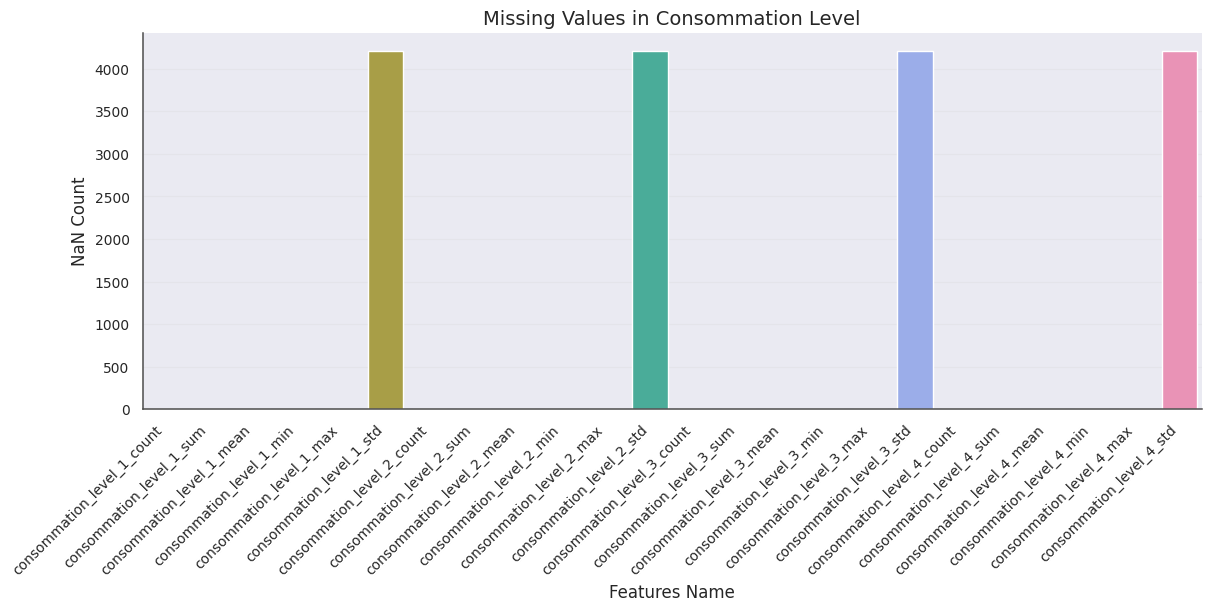

In [8]:
# looking a the consommation
consom_cols = [col for col in train_data_df.columns if "consommation_level" in col]
missing_data = train_data_df[consom_cols].isna().sum()

sns.barplot(
    x=missing_data.index,
    y=missing_data.values
)
plt.title("Missing Values in Consommation Level")
plt.xlabel("Features Name")
plt.ylabel("NaN Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [9]:
# map target
train_data_df = train_data_df.join(pd.get_dummies(
    train_data_df["target"],
    dtype=np.int64,
    drop_first=True,
))

In [50]:
train_data_df.head()

,disrict,client_id,client_catg,region,creation_date,target,consommation_level_1_count,consommation_level_1_sum,consommation_level_1_mean,consommation_level_1_min,...,consommation_level_4_mean,consommation_level_4_min,consommation_level_4_max,consommation_level_4_std,has_elec_sum,has_elec_mean,has_gaz_sum,has_gaz_mean,counter_type_nunique,1.0
0,60,train_Client_0,11,101,1994-12-31,0.0,35,12334,352.400000,38,...,0.000000,0,0,0.000000,35,1.0,0,0.0,1,0
1,69,train_Client_1,11,107,2002-05-29,0.0,37,20629,557.540541,190,...,0.000000,0,0,0.000000,37,1.0,0,0.0,1,0
2,62,train_Client_10,11,301,1986-03-13,0.0,18,14375,798.611111,188,...,0.000000,0,0,0.000000,18,1.0,0,0.0,1,0
3,69,train_Client_100,11,105,1996-07-11,0.0,20,24,1.200000,0,...,0.000000,0,0,0.000000,20,1.0,0,0.0,1,0
4,62,train_Client_1000,11,303,2014-10-14,0.0,14,9292,663.714286,124,...,36.714286,0,382,105.421081,14,1.0,0,0.0,1,0


In [10]:
train_data_df = train_data_df.drop(columns=["target"])
train_data_df = train_data_df.rename(columns={1.0: "target"})

In [121]:
train_data_df.head(3)

,disrict,client_id,client_catg,region,creation_date,consommation_level_1_count,consommation_level_1_sum,consommation_level_1_mean,consommation_level_1_min,consommation_level_1_max,consommation_level_1_std,consommation_level_2_count,consommation_level_2_sum,consommation_level_2_mean,consommation_level_2_min,consommation_level_2_max,consommation_level_2_std,consommation_level_3_count,consommation_level_3_sum,consommation_level_3_mean,consommation_level_3_min,consommation_level_3_max,consommation_level_3_std,consommation_level_4_count,consommation_level_4_sum,consommation_level_4_mean,consommation_level_4_min,consommation_level_4_max,consommation_level_4_std,has_elec_sum,has_elec_mean,has_gaz_sum,has_gaz_mean,counter_type_nunique,target
0,60,train_Client_0,11,101,1994-12-31,35,12334,352.400000,38,1200,310.343472,35,370,10.571429,0,186,43.568935,35,0,0.0,0,0,0.0,35,0,0.0,0,0,0.0,35,1.0,0,0.0,1,0
1,69,train_Client_1,11,107,2002-05-29,37,20629,557.540541,190,1207,197.935960,37,0,0.000000,0,0,0.000000,37,0,0.0,0,0,0.0,37,0,0.0,0,0,0.0,37,1.0,0,0.0,1,0
2,62,train_Client_10,11,301,1986-03-13,18,14375,798.611111,188,2400,513.841374,18,682,37.888889,0,682,160.748942,18,0,0.0,0,0,0.0,18,0,0.0,0,0,0.0,18,1.0,0,0.0,1,0


More insight about the train df


ANALYSIS 2: Energy Type

FRAUD RATE BY ENERGY TYPE (Single Counter):
             Client_Count  Fraud_Rate
energy_type                          
ELEC                73439       0.042
GAZ                   678       0.009


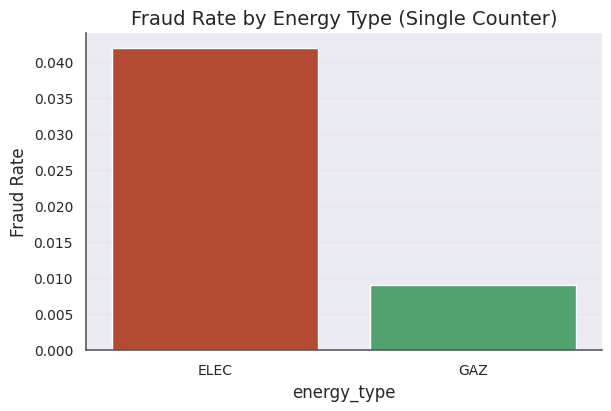

In [11]:
print("\n" + "="*50)
print("ANALYSIS 2: Energy Type")
print("="*50)
energy_results = fh.analyze_energy_type_fraud(train_data_df, custom_viz)


FRAUD RATE BY COUNTER TYPE COUNT:
                      Client_Count  Fraud_Rate
counter_type_nunique                          
1                            74117       0.042
2                            61376       0.072


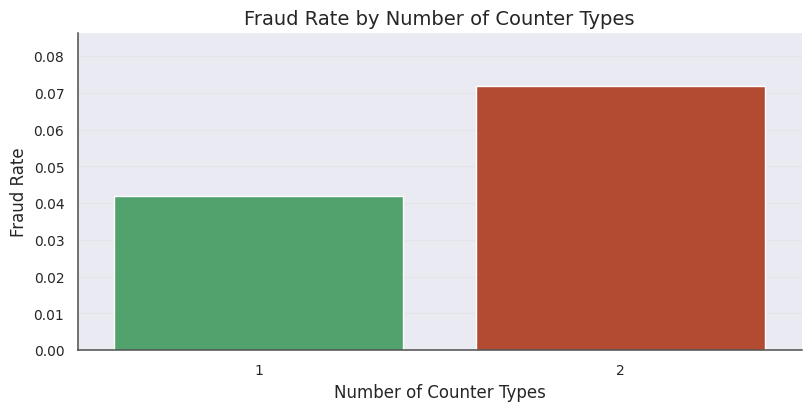

In [13]:
counter_results = fh.analyze_counter_type_fraud(train_data_df, custom_viz)

In [55]:
has_gasdf = train_data_df[(train_data_df["has_gaz_sum"] > 0) & (train_data_df["counter_type_nunique"] == 1)].copy()
has_elecdf = train_data_df[(train_data_df["has_elec_sum"] > 0) & (train_data_df["counter_type_nunique"] == 1)].copy()
has_gas_and_elecdf = train_data_df[(train_data_df["counter_type_nunique"] == 2)].copy()

In [56]:
has_gasdf.head()

,disrict,client_id,client_catg,region,creation_date,consommation_level_1_count,consommation_level_1_sum,consommation_level_1_mean,consommation_level_1_min,consommation_level_1_max,consommation_level_1_std,consommation_level_2_count,consommation_level_2_sum,consommation_level_2_mean,consommation_level_2_min,consommation_level_2_max,consommation_level_2_std,consommation_level_3_count,consommation_level_3_sum,consommation_level_3_mean,consommation_level_3_min,consommation_level_3_max,consommation_level_3_std,consommation_level_4_count,consommation_level_4_sum,consommation_level_4_mean,consommation_level_4_min,consommation_level_4_max,consommation_level_4_std,has_elec_sum,has_elec_mean,has_gaz_sum,has_gaz_mean,counter_type_nunique,target
260,69,train_Client_10023,11,103,2003-06-10,1,1774,1774.000000,1774,1774,NaN,1,0,0.0,0,0,NaN,1,0,0.0,0,0,NaN,1,0,0.0,0,0,NaN,0,0.0,1,1.0,1,0
596,60,train_Client_100532,11,101,1991-01-09,20,108357,5417.850000,3962,9042,1152.465836,20,0,0.0,0,0,0.0,20,0,0.0,0,0,0.0,20,0,0.0,0,0,0.0,0,0.0,20,1.0,1,0
638,69,train_Client_100570,11,104,2016-06-13,8,17875,2234.375000,99,4370,1762.823461,8,0,0.0,0,0,0.0,8,0,0.0,0,0,0.0,8,0,0.0,0,0,0.0,0,0.0,8,1.0,1,0
658,60,train_Client_100589,11,101,2008-12-31,3,508,169.333333,0,508,293.293937,3,0,0.0,0,0,0.0,3,0,0.0,0,0,0.0,3,0,0.0,0,0,0.0,0,0.0,3,1.0,1,0
793,60,train_Client_10071,11,101,2009-09-18,21,0,0.000000,0,0,0.000000,21,0,0.0,0,0,0.0,21,0,0.0,0,0,0.0,21,0,0.0,0,0,0.0,0,0.0,21,1.0,1,0


In [57]:
# consom_cols_00 = [
#     "consommation_level_1_count", "consommation_level_1_mean", "consommation_level_1_std",
#     "consommation_level_2_count", "consommation_level_2_mean", "consommation_level_2_std",
#     "consommation_level_3_count", "consommation_level_3_mean", "consommation_level_3_std",
#     "consommation_level_4_count", "consommation_level_4_mean", "consommation_level_4_std",
# ]

In [59]:
print(f"Gaz: {has_gasdf['consommation_level_1_std'].isna().sum()}")

Gaz: 207


In [60]:
has_gasdf["missing_std_1"] = has_gasdf["consommation_level_1_std"].isna()
has_elecdf["missing_std_1"] = has_elecdf["consommation_level_1_std"].isna()
has_gas_and_elecdf["missing_std_1"] = has_gas_and_elecdf["consommation_level_1_std"].isna()
has_gasdf.head()

,disrict,client_id,client_catg,region,creation_date,consommation_level_1_count,consommation_level_1_sum,consommation_level_1_mean,consommation_level_1_min,consommation_level_1_max,consommation_level_1_std,consommation_level_2_count,consommation_level_2_sum,consommation_level_2_mean,consommation_level_2_min,consommation_level_2_max,consommation_level_2_std,consommation_level_3_count,consommation_level_3_sum,consommation_level_3_mean,consommation_level_3_min,consommation_level_3_max,consommation_level_3_std,consommation_level_4_count,consommation_level_4_sum,consommation_level_4_mean,consommation_level_4_min,consommation_level_4_max,consommation_level_4_std,has_elec_sum,has_elec_mean,has_gaz_sum,has_gaz_mean,counter_type_nunique,target,missing_std_1
260,69,train_Client_10023,11,103,2003-06-10,1,1774,1774.000000,1774,1774,NaN,1,0,0.0,0,0,NaN,1,0,0.0,0,0,NaN,1,0,0.0,0,0,NaN,0,0.0,1,1.0,1,0,True
596,60,train_Client_100532,11,101,1991-01-09,20,108357,5417.850000,3962,9042,1152.465836,20,0,0.0,0,0,0.0,20,0,0.0,0,0,0.0,20,0,0.0,0,0,0.0,0,0.0,20,1.0,1,0,False
638,69,train_Client_100570,11,104,2016-06-13,8,17875,2234.375000,99,4370,1762.823461,8,0,0.0,0,0,0.0,8,0,0.0,0,0,0.0,8,0,0.0,0,0,0.0,0,0.0,8,1.0,1,0,False
658,60,train_Client_100589,11,101,2008-12-31,3,508,169.333333,0,508,293.293937,3,0,0.0,0,0,0.0,3,0,0.0,0,0,0.0,3,0,0.0,0,0,0.0,0,0.0,3,1.0,1,0,False
793,60,train_Client_10071,11,101,2009-09-18,21,0,0.000000,0,0,0.000000,21,0,0.0,0,0,0.0,21,0,0.0,0,0,0.0,21,0,0.0,0,0,0.0,0,0.0,21,1.0,1,0,False


/tmp/ipykernel_344826/3972623479.py:17: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


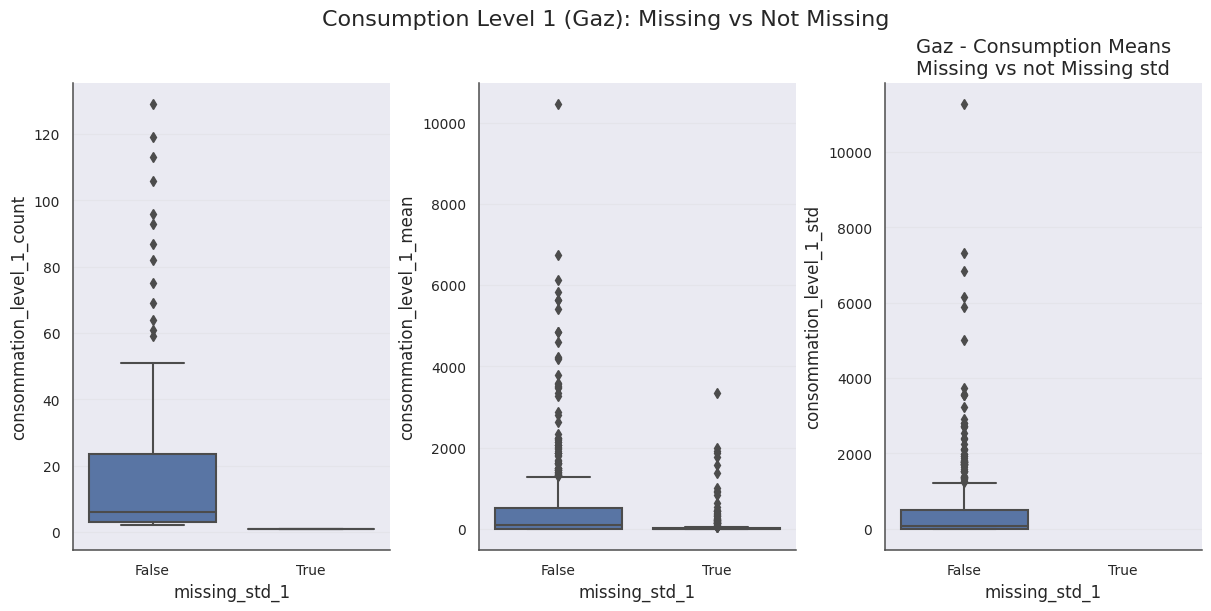

In [ ]:
fh.plot_consumption_distribution(has_gasdf, fh.missing_data_std_1, "Gaz")

/tmp/ipykernel_344826/3972623479.py:17: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


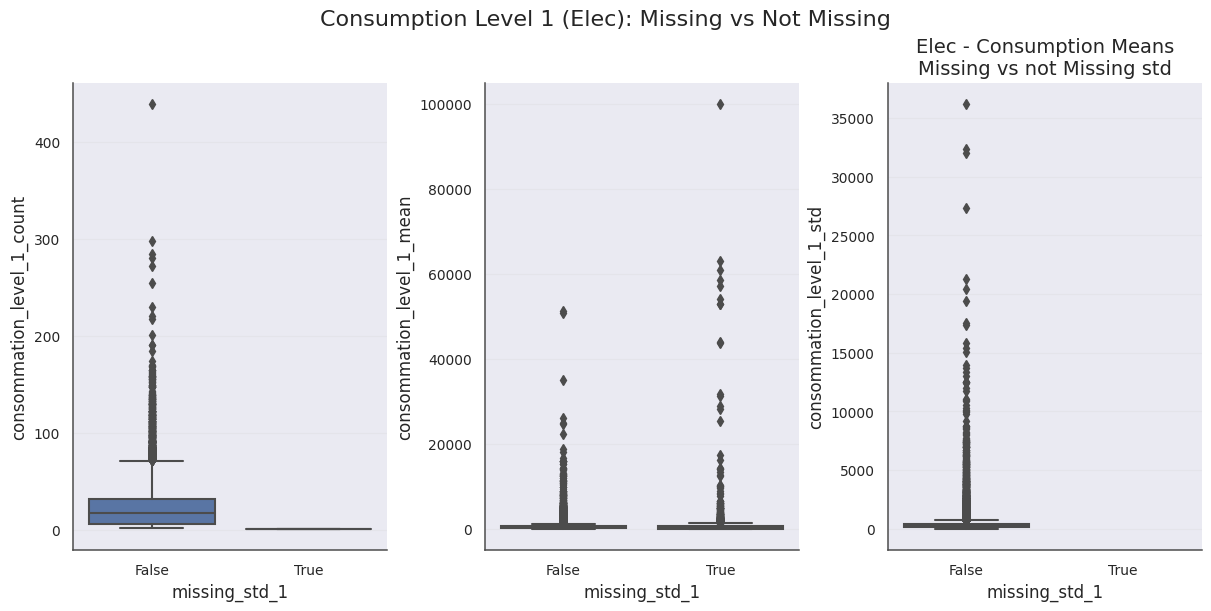

In [ ]:
fh.plot_consumption_distribution(has_elecdf, fh.missing_data_std_1, "Elec")

/tmp/ipykernel_344826/3972623479.py:17: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


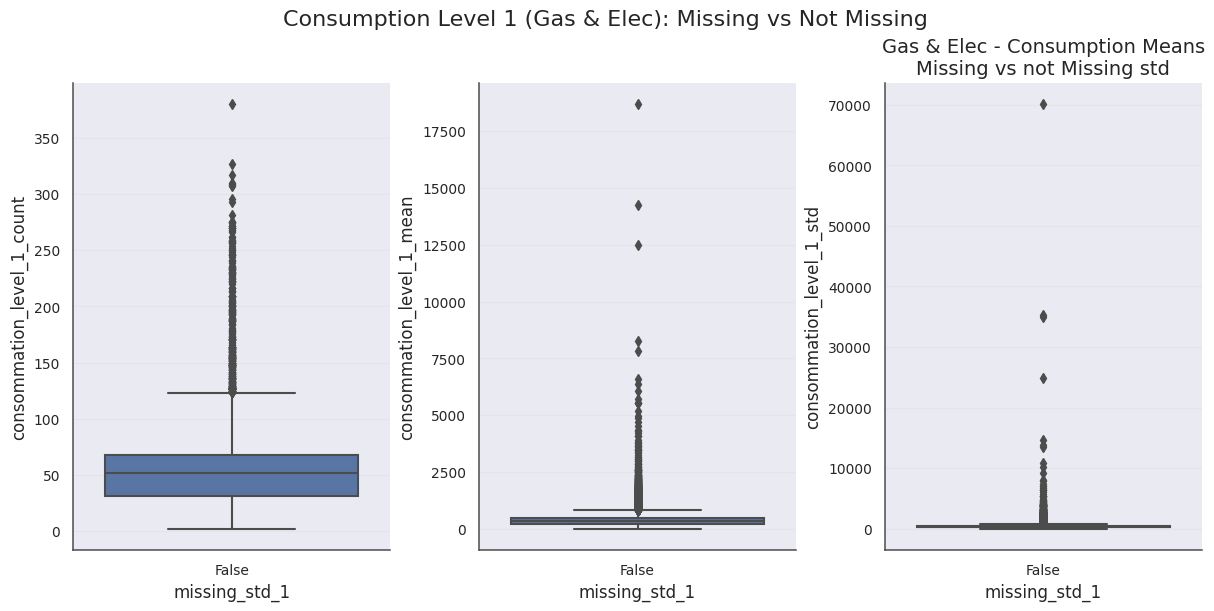

In [ ]:
fh.plot_consumption_distribution(has_gas_and_elecdf, fh.missing_data_std_1, "Gas & Elec")

In [14]:
# providing 0 for null entries in std: no invoice
# train
train_data_df_00 = fh.make_a_copy(train_data_df)
train_data_df_00.head(2)

,disrict,client_id,client_catg,region,creation_date,consommation_level_1_count,consommation_level_1_sum,consommation_level_1_mean,consommation_level_1_min,consommation_level_1_max,...,consommation_level_4_mean,consommation_level_4_min,consommation_level_4_max,consommation_level_4_std,has_elec_sum,has_elec_mean,has_gaz_sum,has_gaz_mean,counter_type_nunique,target
0,60,train_Client_0,11,101,1994-12-31,35,12334,352.400000,38,1200,...,0.0,0,0,0.0,35,1.0,0,0.0,1,0
1,69,train_Client_1,11,107,2002-05-29,37,20629,557.540541,190,1207,...,0.0,0,0,0.0,37,1.0,0,0.0,1,0


In [65]:
train_data_df_00["region"].unique()

array([101, 107, 301, 105, 303, 103, 309, 311, 304, 104, 312, 305, 306,
       308, 372, 307, 313, 310, 371, 302, 106, 379, 399, 206, 199])

In [66]:
train_data_df_00[train_data_df_00["counter_type_nunique"] > 1]

,disrict,client_id,client_catg,region,creation_date,consommation_level_1_count,consommation_level_1_sum,consommation_level_1_mean,consommation_level_1_min,consommation_level_1_max,consommation_level_1_std,consommation_level_2_count,consommation_level_2_sum,consommation_level_2_mean,consommation_level_2_min,consommation_level_2_max,consommation_level_2_std,consommation_level_3_count,consommation_level_3_sum,consommation_level_3_mean,consommation_level_3_min,consommation_level_3_max,consommation_level_3_std,consommation_level_4_count,consommation_level_4_sum,consommation_level_4_mean,consommation_level_4_min,consommation_level_4_max,consommation_level_4_std,has_elec_sum,has_elec_mean,has_gaz_sum,has_gaz_mean,counter_type_nunique,target
5,69,train_Client_10000,11,103,1993-09-29,48,16901,352.104167,0,1414,356.060910,48,501,10.437500,0,400,58.447251,48,181,3.770833,0,181,26.125100,48,0,0.0,0,0,0.0,29,0.604167,19,0.395833,2,0
6,62,train_Client_100000,11,309,2012-06-07,40,11201,280.025000,0,1200,316.711426,40,262,6.550000,0,262,41.425837,40,0,0.000000,0,0,0.000000,40,0,0.0,0,0,0.0,20,0.500000,20,0.500000,2,0
7,60,train_Client_100001,11,101,2006-04-12,78,25545,327.500000,0,1101,293.986648,78,72,0.923077,0,64,7.291285,78,0,0.000000,0,0,0.000000,78,0,0.0,0,0,0.0,40,0.512821,38,0.487179,2,0
10,63,train_Client_100004,12,311,2006-06-30,13,2811,216.230769,11,658,235.580189,13,0,0.000000,0,0,0.000000,13,0,0.000000,0,0,0.000000,13,0,0.0,0,0,0.0,8,0.615385,5,0.384615,2,0
11,62,train_Client_100005,11,304,1997-10-16,76,48297,635.486842,0,2347,437.269726,76,1674,22.026316,0,327,69.160485,76,0,0.000000,0,0,0.000000,76,0,0.0,0,0,0.0,38,0.500000,38,0.500000,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135485,60,train_Client_99992,11,101,2009-03-13,18,10594,588.555556,0,4128,944.282312,18,400,22.222222,0,400,94.280904,18,12,0.666667,0,12,2.828427,18,0,0.0,0,0,0.0,12,0.666667,6,0.333333,2,0
135486,60,train_Client_99993,11,101,2006-11-17,35,8206,234.457143,0,1535,290.587877,35,9266,264.742857,0,1330,338.950486,35,0,0.000000,0,0,0.000000,35,0,0.0,0,0,0.0,25,0.714286,10,0.285714,2,0
135488,62,train_Client_99995,11,304,2004-07-26,71,139,1.957746,0,139,16.496265,71,0,0.000000,0,0,0.000000,71,0,0.000000,0,0,0.000000,71,0,0.0,0,0,0.0,37,0.521127,34,0.478873,2,0
135489,63,train_Client_99996,11,311,2012-10-25,41,7620,185.853659,0,800,200.935258,41,31,0.756098,0,31,4.841387,41,0,0.000000,0,0,0.000000,41,0,0.0,0,0,0.0,20,0.487805,21,0.512195,2,0


In [15]:
# Train set
train_data_df_00 = train_data_df_00.loc[:, fh.final_cols]
train_data_df_00.head(3)

,disrict,client_catg,region,counter_type_nunique,consommation_level_1_min,consommation_level_1_mean,consommation_level_1_max,consommation_level_2_min,consommation_level_2_mean,consommation_level_2_max,consommation_level_3_min,consommation_level_3_mean,consommation_level_3_max,consommation_level_4_min,consommation_level_4_mean,consommation_level_4_max,target
0,60,11,101,1,38,352.400000,1200,0,10.571429,186,0,0.0,0,0,0.0,0,0
1,69,11,107,1,190,557.540541,1207,0,0.000000,0,0,0.0,0,0,0.0,0,0
2,62,11,301,1,188,798.611111,2400,0,37.888889,682,0,0.0,0,0,0.0,0,0


In [68]:
train_data_df_00.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135493 entries, 0 to 135492
Data columns (total 17 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   disrict                    135493 non-null  int64  
 1   client_catg                135493 non-null  int64  
 2   region                     135493 non-null  int64  
 3   counter_type_nunique       135493 non-null  int64  
 4   consommation_level_1_min   135493 non-null  int64  
 5   consommation_level_1_mean  135493 non-null  float64
 6   consommation_level_1_max   135493 non-null  int64  
 7   consommation_level_2_min   135493 non-null  int64  
 8   consommation_level_2_mean  135493 non-null  float64
 9   consommation_level_2_max   135493 non-null  int64  
 10  consommation_level_3_min   135493 non-null  int64  
 11  consommation_level_3_mean  135493 non-null  float64
 12  consommation_level_3_max   135493 non-null  int64  
 13  consommation_level_4_min   13

In [69]:
# no missing values on this selected feats 
train_data_df_00[train_data_df_00.isna()].sum()

disrict                      0.0
client_catg                  0.0
region                       0.0
counter_type_nunique         0.0
consommation_level_1_min     0.0
consommation_level_1_mean    0.0
consommation_level_1_max     0.0
consommation_level_2_min     0.0
consommation_level_2_mean    0.0
consommation_level_2_max     0.0
consommation_level_3_min     0.0
consommation_level_3_mean    0.0
consommation_level_3_max     0.0
consommation_level_4_min     0.0
consommation_level_4_mean    0.0
consommation_level_4_max     0.0
target                       0.0
dtype: float64

In [70]:
train_data_df_00_corr_matrix = train_data_df_00.corr()
train_data_df_00_corr_matrix

,disrict,client_catg,region,counter_type_nunique,consommation_level_1_min,consommation_level_1_mean,consommation_level_1_max,consommation_level_2_min,consommation_level_2_mean,consommation_level_2_max,consommation_level_3_min,consommation_level_3_mean,consommation_level_3_max,consommation_level_4_min,consommation_level_4_mean,consommation_level_4_max,target
disrict,1.000000,0.032836,-0.313309,0.149311,-0.030248,-0.007498,0.024606,-0.008753,-0.020201,-0.000620,-0.002028,0.017698,0.060958,0.006268,0.015458,0.026399,0.050749
client_catg,0.032836,1.000000,-0.041427,-0.024345,0.002056,0.017188,0.065516,0.035487,0.155680,0.150314,0.019216,0.085439,0.115669,0.063304,0.246660,0.322720,0.054745
region,-0.313309,-0.041427,1.000000,-0.084602,-0.009064,-0.032281,-0.032661,-0.012856,-0.060767,-0.046369,-0.012771,-0.060029,-0.096853,-0.016056,-0.051114,-0.065725,0.010940
counter_type_nunique,0.149311,-0.024345,-0.084602,1.000000,-0.106918,-0.067043,0.060643,-0.028517,-0.062424,-0.000405,-0.027675,-0.066923,0.044778,-0.022813,-0.052510,-0.023857,0.065459
consommation_level_1_min,-0.030248,0.002056,-0.009064,-0.106918,1.000000,0.889701,0.202106,0.046604,0.040419,0.002412,0.059182,0.058793,0.011902,0.028213,0.026351,0.007821,-0.020456
consommation_level_1_mean,-0.007498,0.017188,-0.032281,-0.067043,0.889701,1.000000,0.367954,0.031211,0.079445,0.042758,0.042719,0.098222,0.126745,0.016155,0.037018,0.042874,0.005861
consommation_level_1_max,0.024606,0.065516,-0.032661,0.060643,0.202106,0.367954,1.000000,0.000920,0.037885,0.082209,0.003989,0.038982,0.112912,-0.001760,0.015018,0.048513,0.031022
consommation_level_2_min,-0.008753,0.035487,-0.012856,-0.028517,0.046604,0.031211,0.000920,1.000000,0.645932,0.106317,0.054695,0.044960,0.011144,0.023946,0.021333,0.008541,-0.005783
consommation_level_2_mean,-0.020201,0.155680,-0.060767,-0.062424,0.040419,0.079445,0.037885,0.645932,1.000000,0.509508,0.029211,0.104666,0.135109,0.011578,0.100509,0.161704,0.009712
consommation_level_2_max,-0.000620,0.150314,-0.046369,-0.000405,0.002412,0.042758,0.082209,0.106317,0.509508,1.000000,0.001204,0.054104,0.115182,-0.000823,0.073806,0.154099,0.020182


/tmp/ipykernel_344826/3191770324.py:11: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


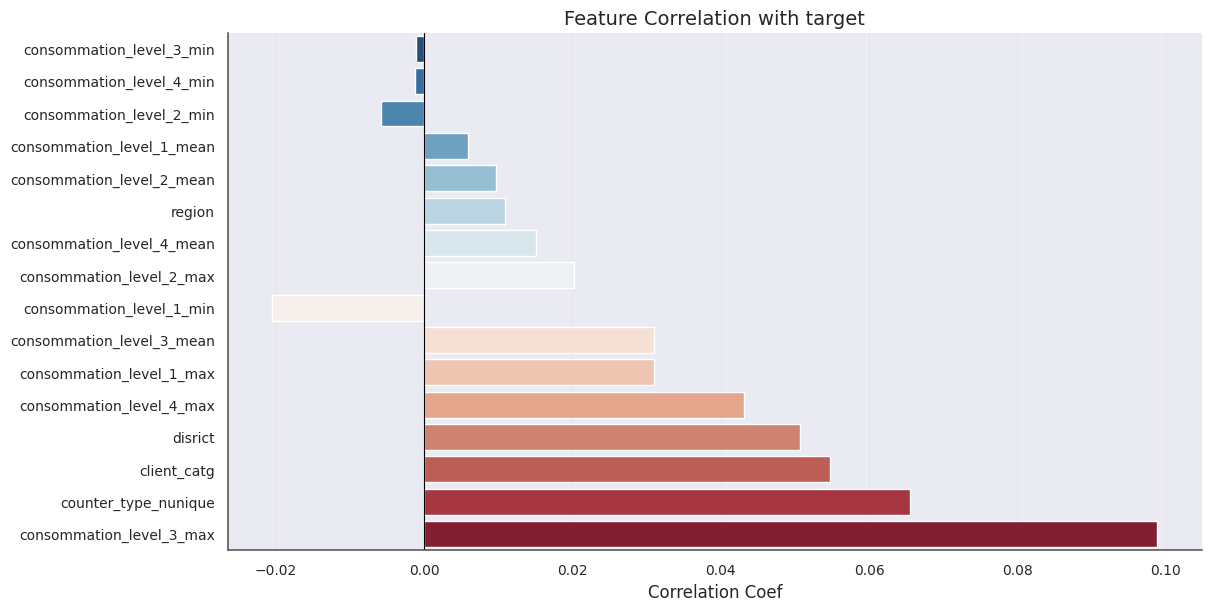

In [71]:
train_data_df_00_corr_matrix_00 = train_data_df_00_corr_matrix["target"].drop("target").sort_values(key=abs, ascending=True)

sns.barplot(
    x=train_data_df_00_corr_matrix_00.values,
    y=train_data_df_00_corr_matrix_00.index,
    palette="RdBu_r"
)
plt.axvline(x=0, color="black", linewidth=0.8)
plt.title("Feature Correlation with target")
plt.xlabel("Correlation Coef")
plt.tight_layout()
plt.show()

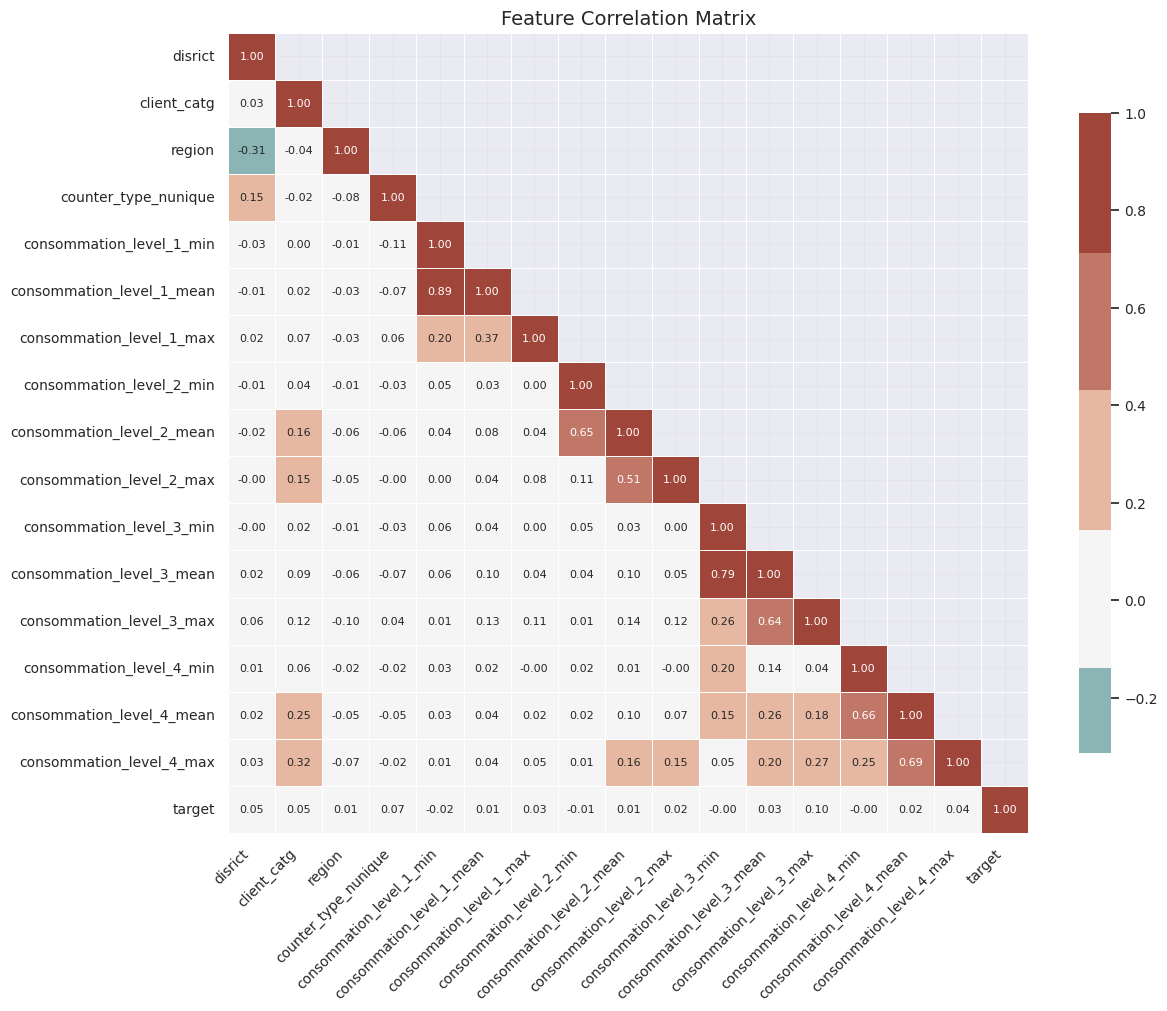

In [72]:
# correlation matrix
# correlation with target seems to be be non existant
# but to the consumption habit of a client is the main feature for this research
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(train_data_df_00_corr_matrix, dtype=bool), k=1)
sns.heatmap(
    train_data_df_00_corr_matrix,
    annot=True,
    center=0,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    mask=mask,
    cbar_kws={"shrink": 0.8},
    annot_kws={"fontsize": 8},
    cmap=custom_viz.CMAP_PALETTE_02
)
plt.title("Feature Correlation Matrix")
plt.xticks(rotation=45, ha="right")
plt.show()

In [73]:
consom_deviation_data = []

for i in range(1, 5):
    consom_deviation_data.append({
        "level": f"Level {i}",
        "mean": train_data_df_00[f"consommation_level_{i}_mean"].mean(),
        "min": train_data_df_00[f"consommation_level_{i}_mean"].min(),
        "max": train_data_df_00[f"consommation_level_{i}_mean"].max(),
    })
consom_deviation_df = pd.DataFrame(consom_deviation_data)
consom_deviation_df

,level,mean,min,max
0,Level 1,432.366021,0.0,99920.000000
1,Level 2,115.334253,0.0,115683.000000
2,Level 3,27.634241,0.0,38526.857143
3,Level 4,73.097981,0.0,79179.777778


/tmp/ipykernel_344826/43536880.py:16: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


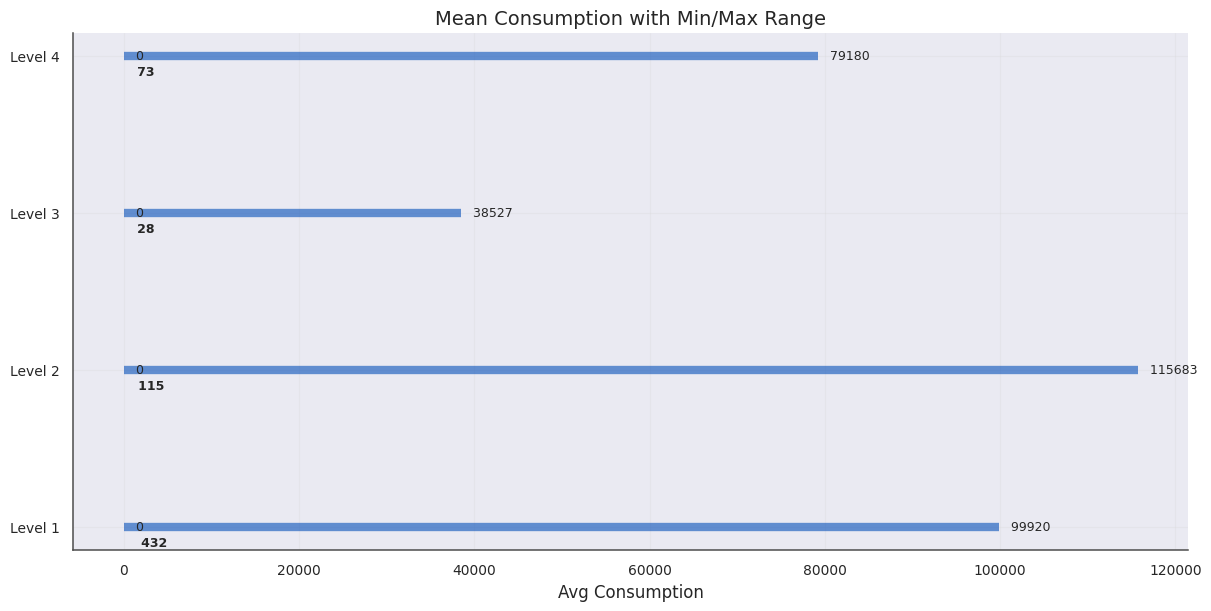

In [74]:
for idx, row in consom_deviation_df.iterrows():
    plt.hlines(
        y=idx, xmin=row["min"], xmax=row["max"],
        colors=custom_viz.PALETTE_BLUE[3],
        linewidth=6,
        alpha=0.6
    )
plt.title("Mean Consumption with Min/Max Range")
plt.yticks(range(len(consom_deviation_df)), consom_deviation_df["level"])
plt.xlabel("Avg Consumption")

for idx, row in consom_deviation_df.iterrows():
    plt.text(row["max"], idx, f"   {row['max']:.0f}", va="center", fontsize=9)
    plt.text(row["min"], idx, f"   {row['min']:.0f}", va="center", fontsize=9)
    plt.text(row["mean"], idx - 0.1, f"   {row['mean']:.0f}", va="center", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.show()

/tmp/ipykernel_344826/952237711.py:14: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


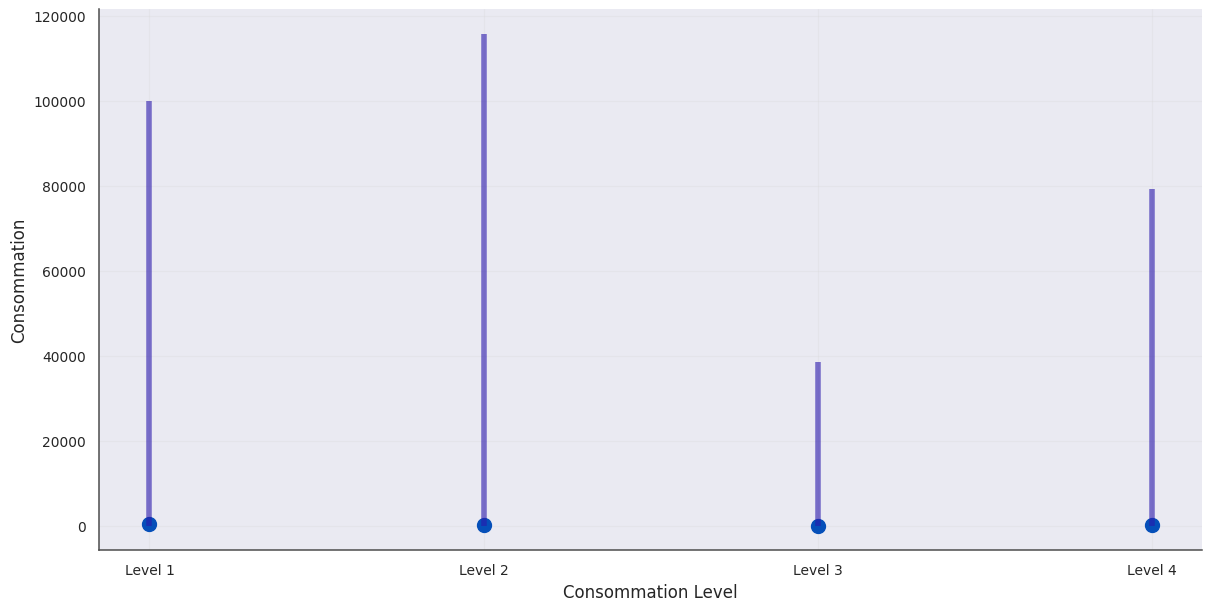

In [75]:
for i in range(1, 5):
    # print(i)
    level =  f"consommation_level_{i}"
    means = train_data_df_00[f"{level}_mean"].mean()
    mins = train_data_df_00[f"{level}_mean"].min()
    maxs = train_data_df_00[f"{level}_mean"].max()
    # print(means)
    plt.scatter(i, means, s=100, color=custom_viz.PALETTE_BLUE[3])
    plt.vlines(i, mins, maxs, color=custom_viz.PALETTE_BLUE[5], linewidth=4, alpha=0.6)

plt.xticks([1, 2, 3, 4], ["Level 1", "Level 2", "Level 3", "Level 4"])
plt.xlabel("Consommation Level")
plt.ylabel("Consommation")
plt.tight_layout()
plt.show()

/tmp/ipykernel_344826/2612192045.py:9: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


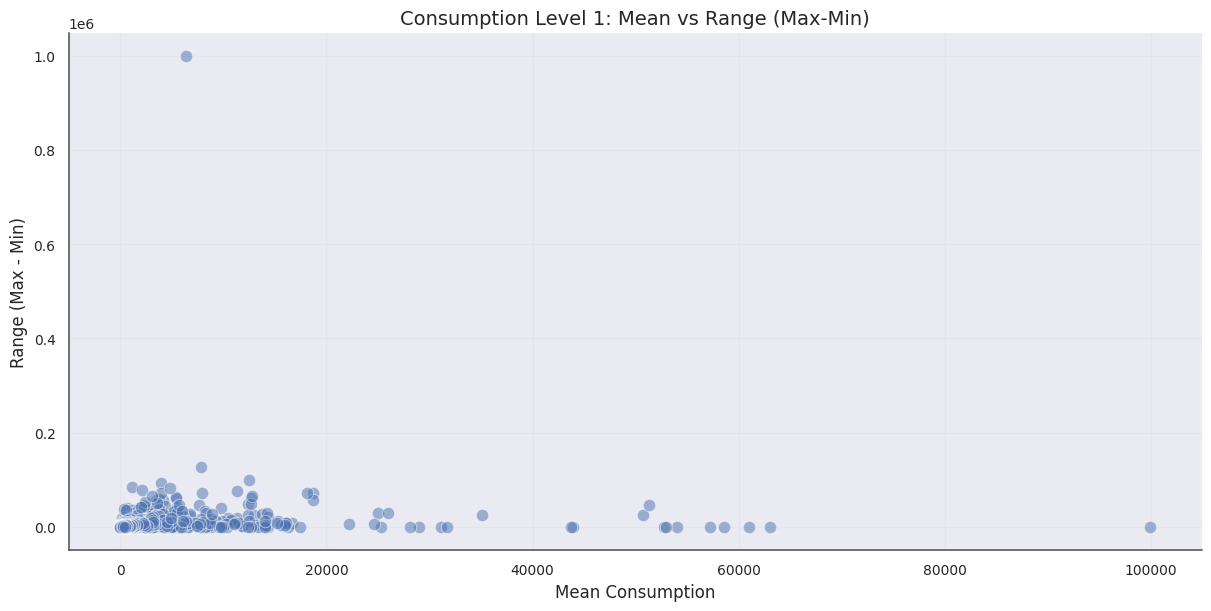

In [76]:
# Scatter: Mean vs Range (max-min)
# train_data_df_00['range_1'] = train_data_df_00['consommation_level_1_max'] - train_data_df_00['consommation_level_1_min']
sns.scatterplot(x='consommation_level_1_mean',
                y=train_data_df_00['consommation_level_1_max'] - train_data_df_00['consommation_level_1_min'], 
                data=train_data_df_00, alpha=0.5, s=80)
plt.title('Consumption Level 1: Mean vs Range (Max-Min)')
plt.xlabel('Mean Consumption')
plt.ylabel('Range (Max - Min)')
plt.tight_layout()
plt.show()


Fraud Rate by counter types

                      count      mean
counter_type_nunique                 
1                     74117  0.042163
2                     61376  0.072357


/tmp/ipykernel_344826/1031928365.py:26: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


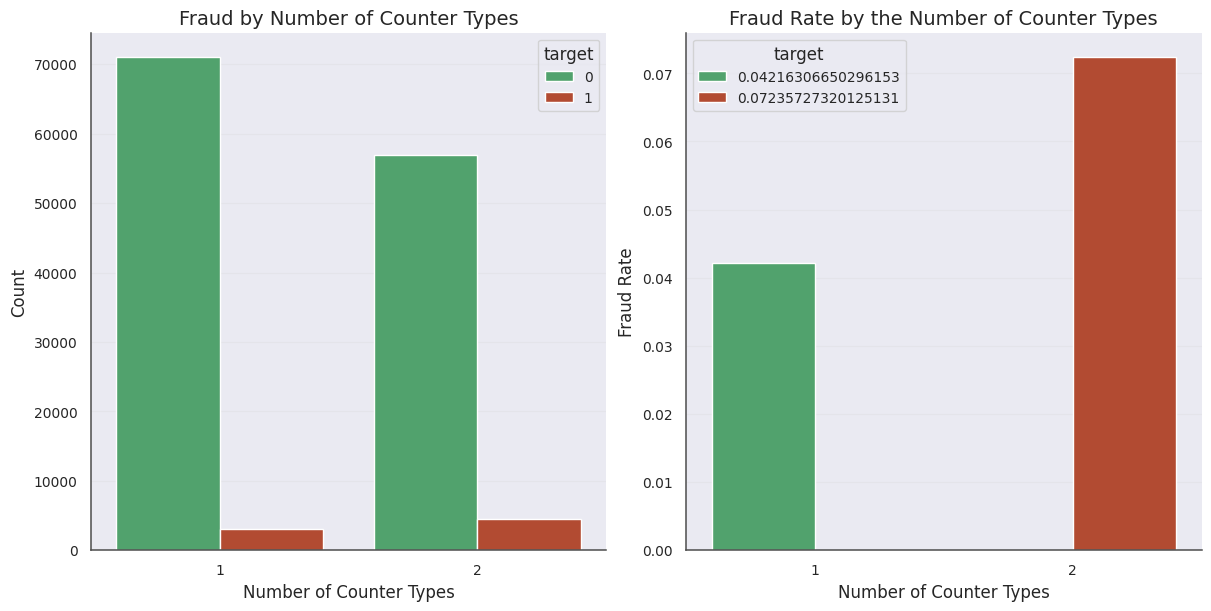

In [77]:
ax1 = plt.subplot(1, 2, 1)
sns.countplot(
    data=train_data_df_00,
    x="counter_type_nunique",
    hue="target",
    palette=custom_viz.MIXED_PALETTE[:2]
)
plt.title("Fraud by Number of Counter Types")
plt.xlabel("Number of Counter Types")
plt.ylabel("Count")

ax2 = plt.subplot(1, 2, 2)

fraud_rate_counter_type = train_data_df_00.groupby("counter_type_nunique")["target"].mean().reset_index()
print(f"\nFraud Rate by counter types\n\n{train_data_df_00.groupby('counter_type_nunique')['target'].agg(['count', 'mean'])}")
sns.barplot(
    data=fraud_rate_counter_type,
    x="counter_type_nunique",
    y="target",
    hue="target",
    palette=custom_viz.MIXED_PALETTE[:2]
)
plt.title("Fraud Rate by the Number of Counter Types")
plt.xlabel("Number of Counter Types")
plt.ylabel("Fraud Rate")
plt.tight_layout()
plt.show()


Fraud Rate by client catg

              count      mean
client_catg                  
11           131494  0.054687
12             2321  0.039638
51             1678  0.168653


/tmp/ipykernel_344826/3570241082.py:27: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


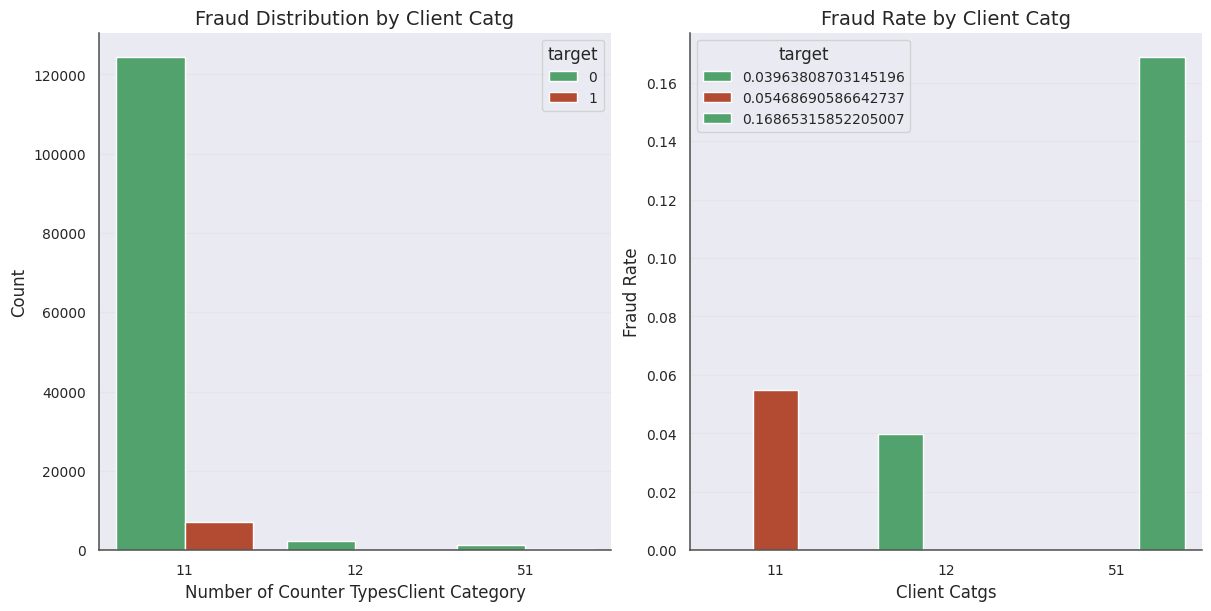

In [78]:
ax1 = plt.subplot(1, 2, 1)
sns.countplot(
    data=train_data_df_00,
    x="client_catg",
    hue="target",
    palette=custom_viz.MIXED_PALETTE[:2]
)
plt.title("Fraud Distribution by Client Catg")
plt.xlabel("Number of Counter TypesClient Category")
plt.ylabel("Count")

ax2 = plt.subplot(1, 2, 2)

fraud_rate_client_catg = train_data_df_00.groupby("client_catg")["target"].mean().reset_index()
print(f"\nFraud Rate by client catg\n\n{train_data_df_00.groupby('client_catg')['target'].agg(['count', 'mean'])}")

sns.barplot(
    data=fraud_rate_client_catg,
    x="client_catg",
    y="target",
    hue="target",
    palette=custom_viz.MIXED_PALETTE[:2]
)
plt.title("Fraud Rate by Client Catg")
plt.xlabel("Client Catgs")
plt.ylabel("Fraud Rate")
plt.tight_layout()
plt.show()


FRAUD BY RATE - CLIENT_CATG
              Count  Fraud_Rate
client_catg                    
51             1678       0.169
11           131494       0.055
12             2321       0.040


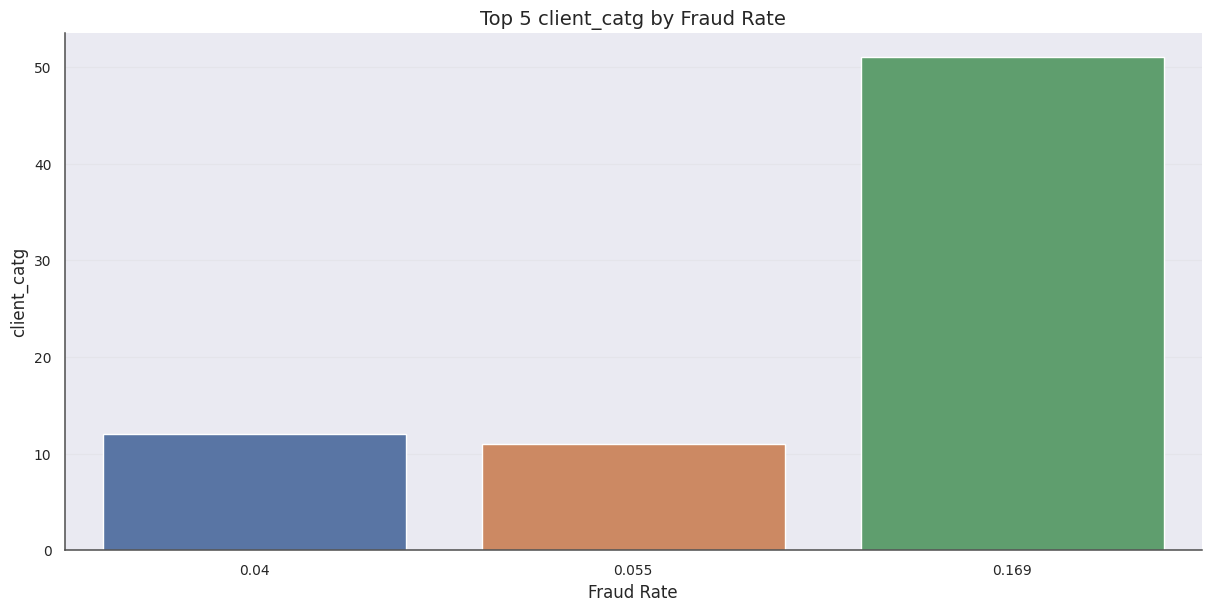


Highest fraud rate: 16.9% (Category: 51)

FRAUD BY RATE - REGION
        Count  Fraud_Rate
region                   
103      8964       0.103
372       644       0.101
311     12406       0.080
106       706       0.075
308       841       0.073


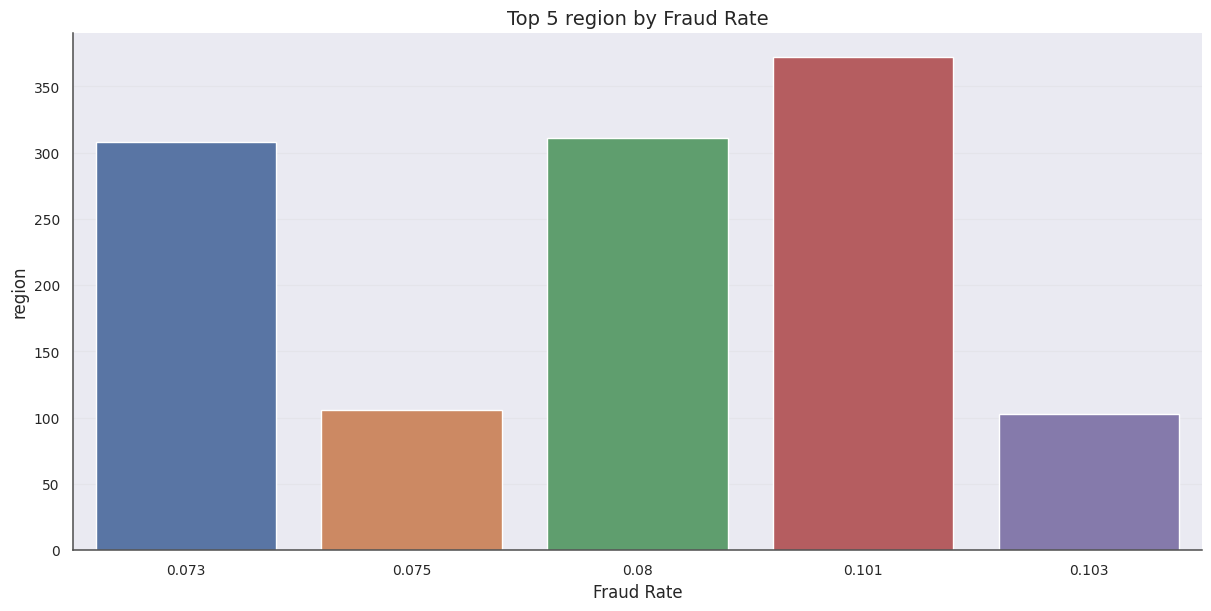


Highest fraud rate: 10.3% (Category: 103)

FRAUD BY RATE - DISRICT
         Count  Fraud_Rate
disrict                   
69       34231       0.071
63       28987       0.065
62       40353       0.052
60       31922       0.036


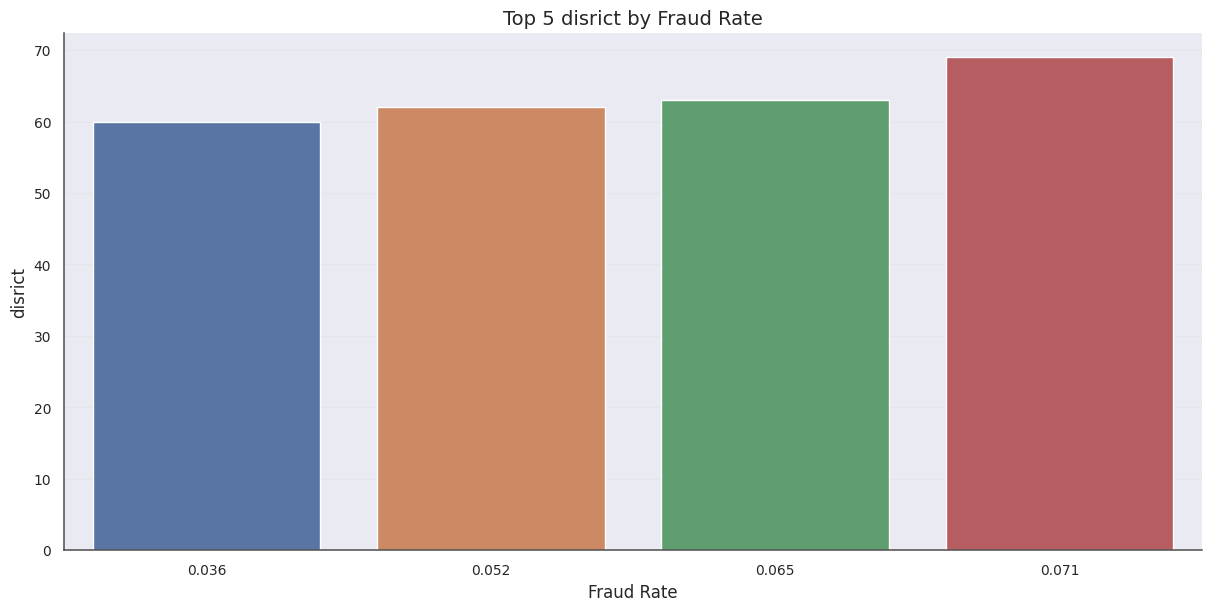


Highest fraud rate: 7.1% (Category: 69)


In [ ]:
# ---- here we go -----
fh.fraud_rate_catg_features(train_data_df_00)

### 3. ML

__3.1 Train and Test Sets__

In [17]:
# prepare the test set starting with the agg like in the train set
invoice_test_df_agg = fh.agg_invoice(invoice_test_df_00, fh.invoice_agg_dict)
invoice_test_df_agg = fh.agg_invoice_add_counter_type(invoice_test_df_00, invoice_test_df_agg)

# merge the train set
test_data_df = client_test_df_00.merge(invoice_test_df_agg, on="client_id", how="left")
test_data_df.head(3)

,disrict,client_id,client_catg,region,creation_date,consommation_level_1_count,consommation_level_1_sum,consommation_level_1_mean,consommation_level_1_min,consommation_level_1_max,...,consommation_level_4_sum,consommation_level_4_mean,consommation_level_4_min,consommation_level_4_max,consommation_level_4_std,has_elec_sum,has_elec_mean,has_gaz_sum,has_gaz_mean,counter_type_nunique
0,62,test_Client_0,11,307,2002-05-28,37,18061,488.135135,0,1090,...,0,0.000000,0,0,0.000000,37,1.000000,0,0.000000,1
1,69,test_Client_1,11,103,2009-08-06,22,24011,1091.409091,11,3600,...,12899,586.318182,0,12899,2750.076040,22,1.000000,0,0.000000,1
2,62,test_Client_10,11,310,2004-04-07,74,40999,554.040541,0,1200,...,12,0.162162,0,12,1.394972,42,0.567568,32,0.432432,2


In [18]:
# because we will not deal with the std, which has nan values,
# we will then reduce the cols of the test set as made with the train set, removing the target
test_data_df_00 = test_data_df.loc[:, fh.final_cols[: -1]].copy()
test_data_df_00.head(3)

,disrict,client_catg,region,counter_type_nunique,consommation_level_1_min,consommation_level_1_mean,consommation_level_1_max,consommation_level_2_min,consommation_level_2_mean,consommation_level_2_max,consommation_level_3_min,consommation_level_3_mean,consommation_level_3_max,consommation_level_4_min,consommation_level_4_mean,consommation_level_4_max
0,62,11,307,1,0,488.135135,1090,0,3.243243,120,0,0.000000,0,0,0.000000,0
1,69,11,103,1,11,1091.409091,3600,0,843.136364,4053,0,182.318182,1144,0,586.318182,12899
2,62,11,310,2,0,554.040541,1200,0,37.364865,400,0,15.743243,800,0,0.162162,12


In [82]:
train_data_df_00.head(3)

,disrict,client_catg,region,counter_type_nunique,consommation_level_1_min,consommation_level_1_mean,consommation_level_1_max,consommation_level_2_min,consommation_level_2_mean,consommation_level_2_max,consommation_level_3_min,consommation_level_3_mean,consommation_level_3_max,consommation_level_4_min,consommation_level_4_mean,consommation_level_4_max,target
0,60,11,101,1,38,352.400000,1200,0,10.571429,186,0,0.0,0,0,0.0,0,0
1,69,11,107,1,190,557.540541,1207,0,0.000000,0,0,0.0,0,0,0.0,0,0
2,62,11,301,1,188,798.611111,2400,0,37.888889,682,0,0.0,0,0,0.0,0,0


In [83]:
# check if the cols cols for train and test are the same
print("="*100)
print(f"{'|':40} Final Col {'':48}{'|'}")
print("="*100)
print(f"Train data shape: {train_data_df_00.shape}")
print(f"Test data shape: {test_data_df_00.shape}\n")
print(f"Train columns: {train_data_df_00.columns.tolist()}")
print()
print(f"Test columns: {test_data_df_00.columns.tolist()}")
print(f"\nColumns match: {all(train_data_df_00.columns[:-1] == test_data_df_00.columns)}")

|                                        Final Col                                                 |
Train data shape: (135493, 17)
Test data shape: (58069, 16)

Train columns: ['disrict', 'client_catg', 'region', 'counter_type_nunique', 'consommation_level_1_min', 'consommation_level_1_mean', 'consommation_level_1_max', 'consommation_level_2_min', 'consommation_level_2_mean', 'consommation_level_2_max', 'consommation_level_3_min', 'consommation_level_3_mean', 'consommation_level_3_max', 'consommation_level_4_min', 'consommation_level_4_mean', 'consommation_level_4_max', 'target']

Test columns: ['disrict', 'client_catg', 'region', 'counter_type_nunique', 'consommation_level_1_min', 'consommation_level_1_mean', 'consommation_level_1_max', 'consommation_level_2_min', 'consommation_level_2_mean', 'consommation_level_2_max', 'consommation_level_3_min', 'consommation_level_3_mean', 'consommation_level_3_max', 'consommation_level_4_min', 'consommation_level_4_mean', 'consommation_level_4_ma

In [19]:
# Training data no need of sklearn train_test_split meths
X_train = train_data_df_00.drop(columns=["target"]).copy()
y_train = train_data_df_00["target"].copy()
# Test set
X_test = test_data_df_00.copy()

In [85]:
# Check for missing values
print(f"Missing values in X_train: {X_train.isna().sum().sum()}")
print(f"Missing values in X_test: {X_test.isna().sum().sum()}")

Missing values in X_train: 0
Missing values in X_test: 0


__3.2. Setup data for training__

__3.3. Start training__

In [ ]:
training_summary = fh.run_training(
    fh.features_sets, 
    fh.models,
    X_train, y_train, X_test
)


FEATURE SET: main_features

           RandomForestClassifier (scaled: False)...
Fitting 3 folds for each of 18 candidates, totalling 54 fits


[CV] END ......criterion=gini, max_depth=10, n_estimators=50; total time=  18.5s
[CV] END ......criterion=gini, max_depth=10, n_estimators=50; total time=  18.3s
[CV] END ......criterion=gini, max_depth=10, n_estimators=50; total time=  19.0s
[CV] END ....criterion=gini, max_depth=None, n_estimators=50; total time=  21.5s
[CV] END ....criterion=gini, max_depth=None, n_estimators=50; total time=  22.3s
[CV] END ....criterion=gini, max_depth=None, n_estimators=50; total time=  23.0s
[CV] END .criterion=entropy, max_depth=None, n_estimators=50; total time=  28.1s
[CV] END .....criterion=gini, max_depth=10, n_estimators=100; total time=  28.7s
[CV] END .criterion=entropy, max_depth=None, n_estimators=50; total time=  29.3s
[CV] END .....criterion=gini, max_depth=10, n_estimators=100; total time=  35.0s
[CV] END ...criterion=gini, max_depth=None, n_estimators=100; total time=  36.1s
[CV] END .....criterion=gini, max_depth=10, n_estimators=100; total time=  34.4s
[CV] END ...criterion=gini, 

/home/rackkoun/Documents/Workspaces/neuefishe/projects/week-07/ds-ml-project/.week07env/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END ................................C=0.01, solver=saga; total time= 1.3min


/home/rackkoun/Documents/Workspaces/neuefishe/projects/week-07/ds-ml-project/.week07env/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


...

[CV] END alpha=0.01, learning_rate=optimal, loss=log_loss, penalty=l1; total time= 2.0min


/home/rackkoun/Documents/Workspaces/neuefishe/projects/week-07/ds-ml-project/.week07env/lib/python3.11/site-packages/sklearn/linear_model/_stochastic_gradient.py:702: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


[CV] END alpha=0.1, learning_rate=optimal, loss=log_loss, penalty=l1; total time= 2.1min

           SGDClassifier (scaled: True)...
Fitting 3 folds for each of 6 candidates, totalling 18 fits


/home/rackkoun/Documents/Workspaces/neuefishe/projects/week-07/ds-ml-project/.week07env/lib/python3.11/site-packages/sklearn/linear_model/_stochastic_gradient.py:702: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


[CV] END alpha=0.01, learning_rate=optimal, loss=log_loss, penalty=l2; total time=   0.3s
[CV] END alpha=0.1, learning_rate=optimal, loss=log_loss, penalty=l2; total time=   0.3s
[CV] END alpha=0.01, learning_rate=optimal, loss=log_loss, penalty=l1; total time=   0.4s
[CV] END alpha=0.01, learning_rate=optimal, loss=log_loss, penalty=l1; total time=   0.4s
[CV] END alpha=0.1, learning_rate=optimal, loss=log_loss, penalty=l2; total time=   0.3s
[CV] END alpha=0.01, learning_rate=optimal, loss=log_loss, penalty=l1; total time=   0.4s
[CV] END alpha=0.001, learning_rate=optimal, loss=log_loss, penalty=l1; total time=   0.4s
[CV] END alpha=0.01, learning_rate=optimal, loss=log_loss, penalty=l2; total time=   0.4s
[CV] END alpha=0.1, learning_rate=optimal, loss=log_loss, penalty=l2; total time=   0.4s
[CV] END alpha=0.001, learning_rate=optimal, loss=log_loss, penalty=l2; total time=   0.4s
[CV] END alpha=0.1, learning_rate=optimal, loss=log_loss, penalty=l1; total time=   0.4s
[CV] END alp

In [87]:
training_summary.shape

(8, 10)


    BEST MODEL: RandomForestClassifier (scaled: False)
          Val ROC-AUC: 0.739
          Train ROC-AUC: 0.802


/tmp/ipykernel_344826/3157168187.py:64: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


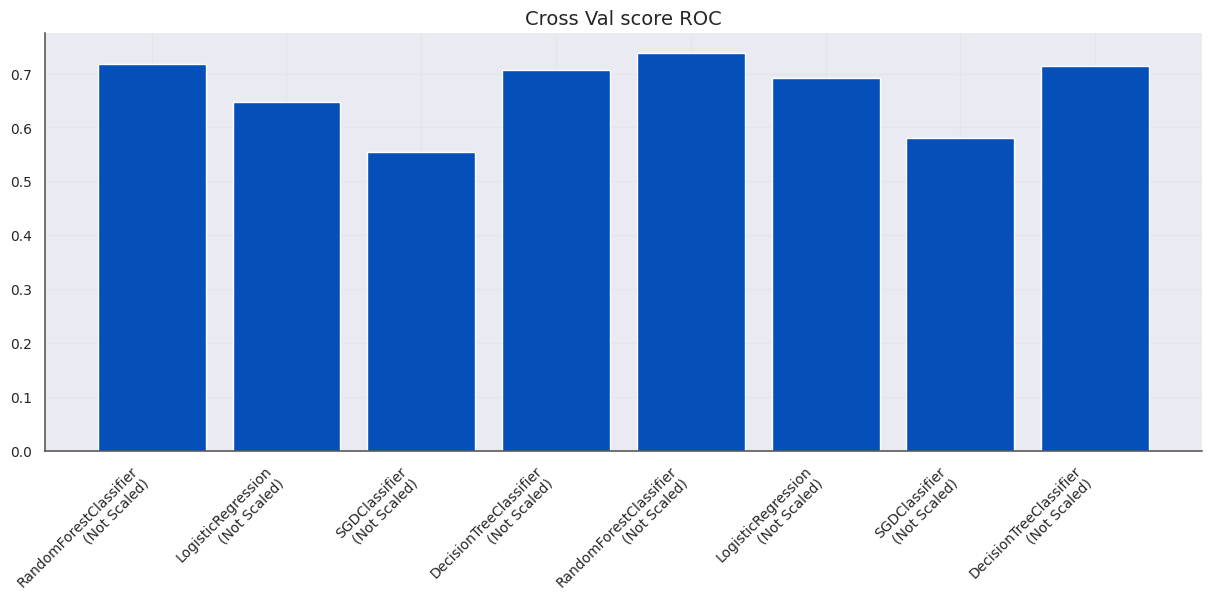

In [ ]:
fh.plot_models_summary(training_summary, custom_viz)

/tmp/ipykernel_344826/3157168187.py:78: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


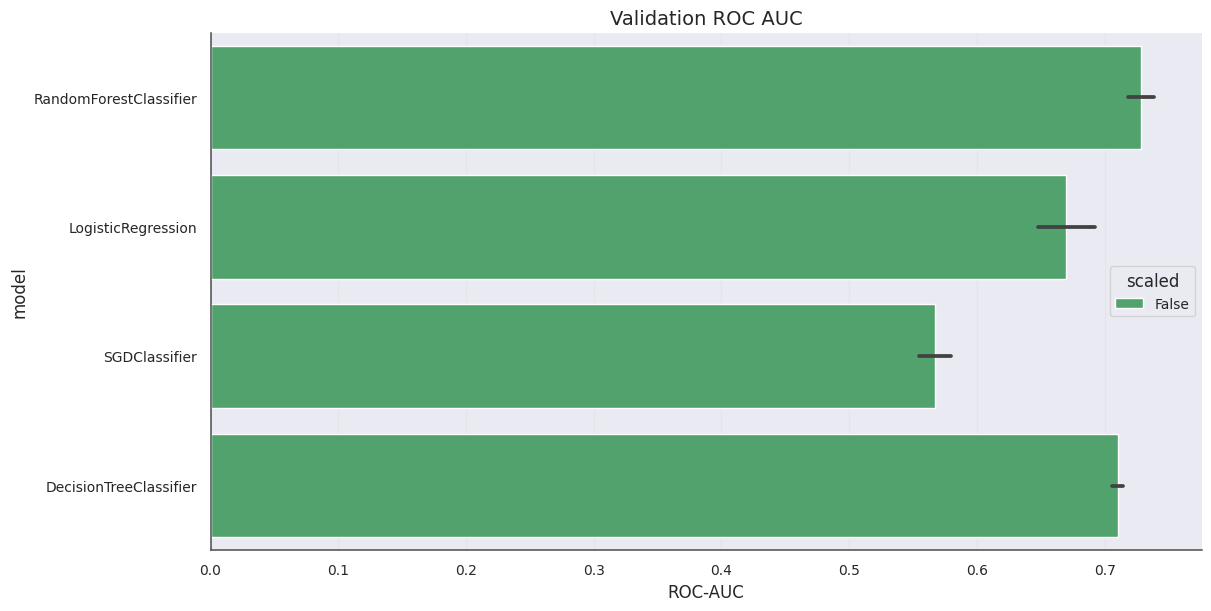

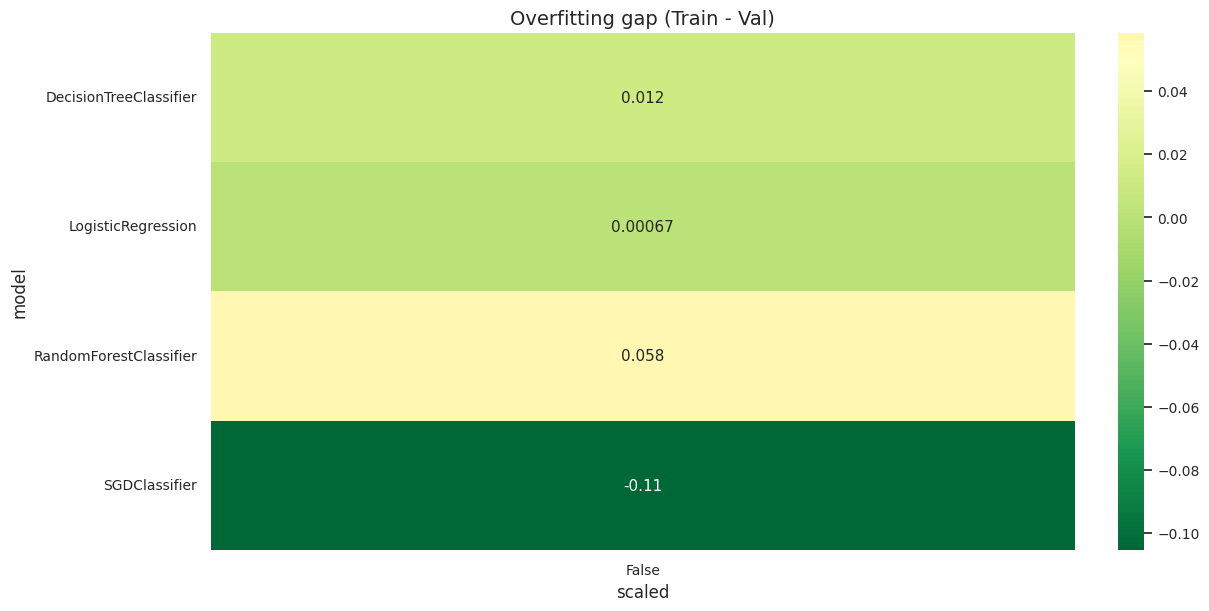

In [ ]:
fh.plot_overfitting_detection(training_summary, custom_viz)

In [90]:
# get best model config
best_estimator_row = training_summary.loc[training_summary["val_roc"].idxmax()]
# best_estimator_name = training_summary.loc[training_summary["val_roc"].idxmax(), "model"]
best_estimator_row

model                                         RandomForestClassifier
scaled                                                         False
train_acc                                                    0.69935
train_roc                                                   0.801947
val_roc                                                     0.738998
y_pred             [0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, ...
y_pred_proba       [0.49207024830811086, 0.7914329288298779, 0.60...
best_model         (DecisionTreeClassifier(criterion='entropy', m...
best_params        {'criterion': 'entropy', 'max_depth': 10, 'n_e...
overfitting_gap                                             0.062949
Name: 4, dtype: object


                          Confusion Matrix (from cross val)

                          Model Name: RandomForestClassifier)
[[TN: 90316, FP: 37611]]
[[FN: 2974, TP: 4592]]


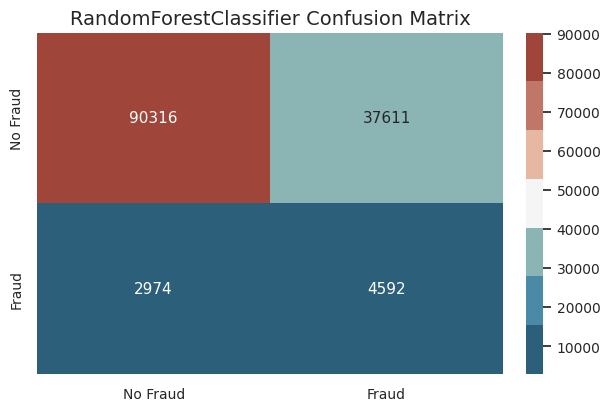

In [ ]:
cm = fh.plot_conf_mat_from_cv(
    best_estimator_row["model"], 
    {"model": best_estimator_row["best_model"]},
    X_train[fh.main_feature_cols], y_train,
    custom_viz
)


Report (before transpose):
                       0            1  accuracy      macro avg   weighted avg
precision       0.968121     0.108807  0.700464       0.538464       0.920136
recall          0.705996     0.606926  0.700464       0.656461       0.700464
f1-score        0.816538     0.184533  0.700464       0.500535       0.781246
support    127927.000000  7566.000000  0.700464  135493.000000  135493.000000

Report (after transpose):
              precision    recall  f1-score        support
0              0.968121  0.705996  0.816538  127927.000000
1              0.108807  0.606926  0.184533    7566.000000
accuracy       0.700464  0.700464  0.700464       0.700464
macro avg      0.538464  0.656461  0.500535  135493.000000
weighted avg   0.920136  0.700464  0.781246  135493.000000


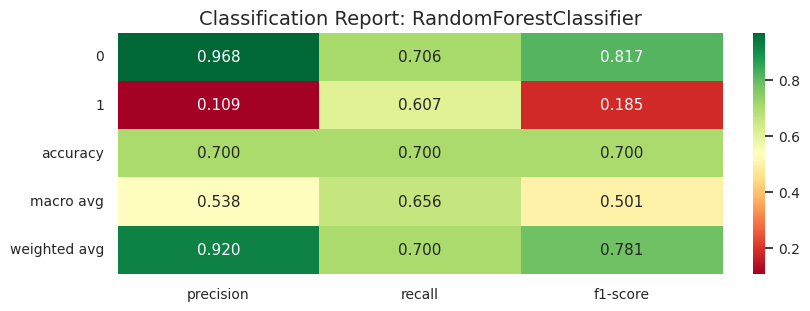

In [ ]:
report_df = fh.plot_classification_report_cv(
    best_estimator_row["model"], 
    {"model": best_estimator_row["best_model"]},
    X_train[fh.main_feature_cols], y_train
)

In [93]:
# best_idx = training_summary["val_roc"].idxmax()
# training_summary.loc[best_idx]
best_row = training_summary.loc[training_summary["val_roc"].idxmax()]
best_row

model                                         RandomForestClassifier
scaled                                                         False
train_acc                                                    0.69935
train_roc                                                   0.801947
val_roc                                                     0.738998
y_pred             [0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, ...
y_pred_proba       [0.49207024830811086, 0.7914329288298779, 0.60...
best_model         (DecisionTreeClassifier(criterion='entropy', m...
best_params        {'criterion': 'entropy', 'max_depth': 10, 'n_e...
overfitting_gap                                             0.062949
Name: 4, dtype: object

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
/tmp/ipykernel_344826/1866658941.py:30: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


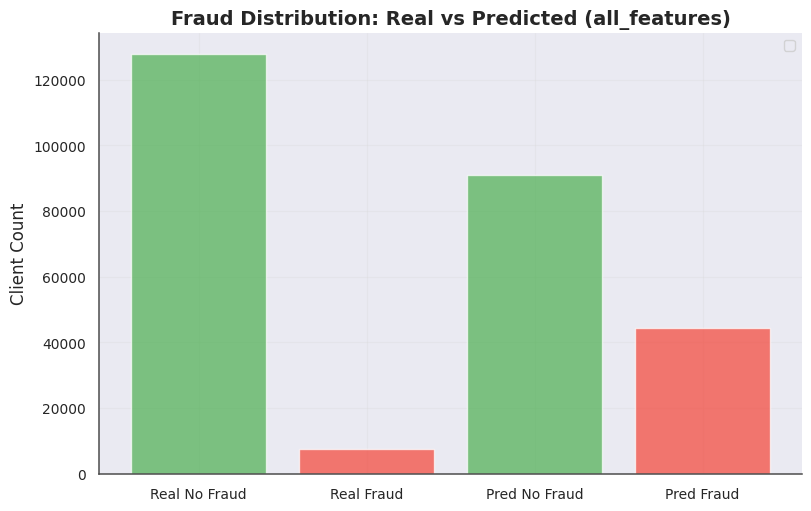

Model: RandomForestClassifier
Feature set: all_features (16 features)
Real fraud: 7566 (5.6%)
Pred fraud: 44452 (32.8%)


In [ ]:
fh.plot_fraud_distribution(X_train, y_train, training_summary, fh.main_feature_cols, fh.final_cols)

__Hypothesis tested__

- Counter types: Does having 2 counter types increase fraud?
- Energy type: Does ELEC or GAZ have higher fraud rate?
- Client category: Which category (11, 12, 51) is riskiest?
- Region/District: Are certain areas fraud hotspots?

In [ ]:
fh.interpret_model_summary(training_summary, train_data_df_00)


BEST: RandomForestClassifier | ROC-AUC: 0.739
Multi-counter fraud: 7.2% | Single: 4.2%
Ratio: 1.7x more fraud
  GOOD performance


## recap
- Model ROC-AUC 0.739 = GOOD (catches ~74% of fraud patterns)
- Multi-counter clients likely have higher fraud risk

In [ ]:
# model metadata
model_package = fh.save_best_model(training_summary, X_train, fh.features_sets, MODEL_PATH)
model_package

Saving model trained with: all_features (16)
Model saved to: /home/rackkoun/Documents/Workspaces/neuefishe/projects/week-07/ds-ml-project/models/fraud_detection_elec_gaz.pkl
Author: Rackkoun
ROC-AUC: 0.739


{'model': RandomForestClassifier(class_weight='balanced', criterion='entropy',
                        max_depth=10, n_estimators=200, n_jobs=-1,
                        random_state=42),
 'metadata': {'author': 'Rackkoun',
  'model_name': 'RandomForestClassifier',
  'val_roc_auc': 0.7389977264808936,
  'overfitting_gap': 0.06294916865981637,
  'best_params': {'criterion': 'entropy',
   'max_depth': 10,
   'n_estimators': 200},
  'saved_date': '2025-12-19 20:04:46',
  'features_set': 'all_features',
  'features_used': ['disrict',
   'client_catg',
   'region',
   'counter_type_nunique',
   'consommation_level_1_min',
   'consommation_level_1_mean',
   'consommation_level_1_max',
   'consommation_level_2_min',
   'consommation_level_2_mean',
   'consommation_level_2_max',
   'consommation_level_3_min',
   'consommation_level_3_mean',
   'consommation_level_3_max',
   'consommation_level_4_min',
   'consommation_level_4_mean',
   'consommation_level_4_max'],
  'n_features': 16,
  'n_samp

In [ ]:
fraud_model, model_metadata = fh.load_model(MODEL_PATH)

Model loaded from: /home/rackkoun/Documents/Workspaces/neuefishe/projects/week-07/ds-ml-project/models/fraud_detection_elec_gaz.pkl
Author: Rackkoun
ROC-AUC: 0.7389977264808936
Features: ['disrict', 'client_catg', 'region', 'counter_type_nunique', 'consommation_level_1_min', 'consommation_level_1_mean', 'consommation_level_1_max', 'consommation_level_2_min', 'consommation_level_2_mean', 'consommation_level_2_max', 'consommation_level_3_min', 'consommation_level_3_mean', 'consommation_level_3_max', 'consommation_level_4_min', 'consommation_level_4_mean', 'consommation_level_4_max']


In [102]:
predictions = fraud_model.predict_proba(X_test[model_metadata["features_used"]])[:, 1]

/home/rackkoun/Documents/Workspaces/neuefishe/projects/week-07/ds-ml-project/.week07env/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [103]:
print(f"Predictions made: {len(predictions)}")
print(f"Fraud Rate Predictions: {predictions.mean():.2%}")

Predictions made: 58069
Fraud Rate Predictions: 39.00%
